In [1]:
import os
import sys

print(os.getcwd())
# 1. Navigate UP two levels to the project root:
#    preparation/ -> CST-Part-II-Project-Code/
os.chdir('..') # Go up one level (out of preparation)

# 2. Check the path again. We should now be in the project root.
#    You don't need to go up another level, as the previous failed attempt
#    must have been a result of not resetting the environment first.
#    We will confirm and then add the current directory ('.').

# 3. Add the project root (the directory containing 'src') to sys.path
#    The '.' refers to the Current Working Directory, which is now the project root.
#if '.' not in sys.path:
#    sys.path.append('.')

# Check the final working directory (optional, but helpful for confirmation)
print(f"New CWD for imports: {os.getcwd()}")
print("System path successfully configured.")

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code\color_code_experiments
New CWD for imports: C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code
System path successfully configured.


In [2]:
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import ColorCodeCircuit666

In [3]:
import stim

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(3, 1) 4
QUBIT_COORDS(3, 3) 5
QUBIT_COORDS(4, 0) 6
QUBIT_COORDS(4, 2) 7
QUBIT_COORDS(5, 1) 8
QUBIT_COORDS(6, 0) 9
R 0 2 3 4 5 8 9
X_ERROR(0.01) 0 2 3 4 5 8 9
R 1 6 7
X_ERROR(0.01) 1 6 7
TICK
RX 6 1 7
Z_ERROR(0.01) 6 1 7
TICK
CX 1 0 7 4
DEPOLARIZE2(0.01) 1 0 7 4
DEPOLARIZE1(0.01) 2 3 5 8 9 6
TICK
CX 1 2 7 8
DEPOLARIZE2(0.01) 1 2 7 8
DEPOLARIZE1(0.01) 0 3 4 5 9 6
TICK
CX 6 2 7 3
DEPOLARIZE2(0.01) 6 2 7 3
DEPOLARIZE1(0.01) 0 4 5 8 9 1
TICK
CX 6 9 1 4
DEPOLARIZE2(0.01) 6 9 1 4
DEPOLARIZE1(0.01) 0 2 3 5 8 7
TICK
CX 6 4 7 5
DEPOLARIZE2(0.01) 6 4 7 5
DEPOLARIZE1(0.01) 0 2 3 8 9 1
TICK
CX 6 8 1 3
DEPOLARIZE2(0.01) 6 8 1 3
DEPOLARIZE1(0.01) 0 2 4 5 9 7
TICK
MX(0.01) 6 1 7
DEPOLARIZE1(0.01) 0 2 3 4 5 8 9
R 6 1 7
X_ERROR(0.01) 6 1 7
TICK
CX 0 1 4 7
DEPOLARIZE2(0.01) 0 1 4 7
DEPOLARIZE1(0.01) 2 3 5 8 9 6
TICK
CX 2 1 8 7
DEPOLARIZE2(0.01) 2 1 8 7
DEPOLARIZE1(0.01) 0 3 4 5 9 6
TICK
CX 2 6 3 7
DEPOLARIZE2(

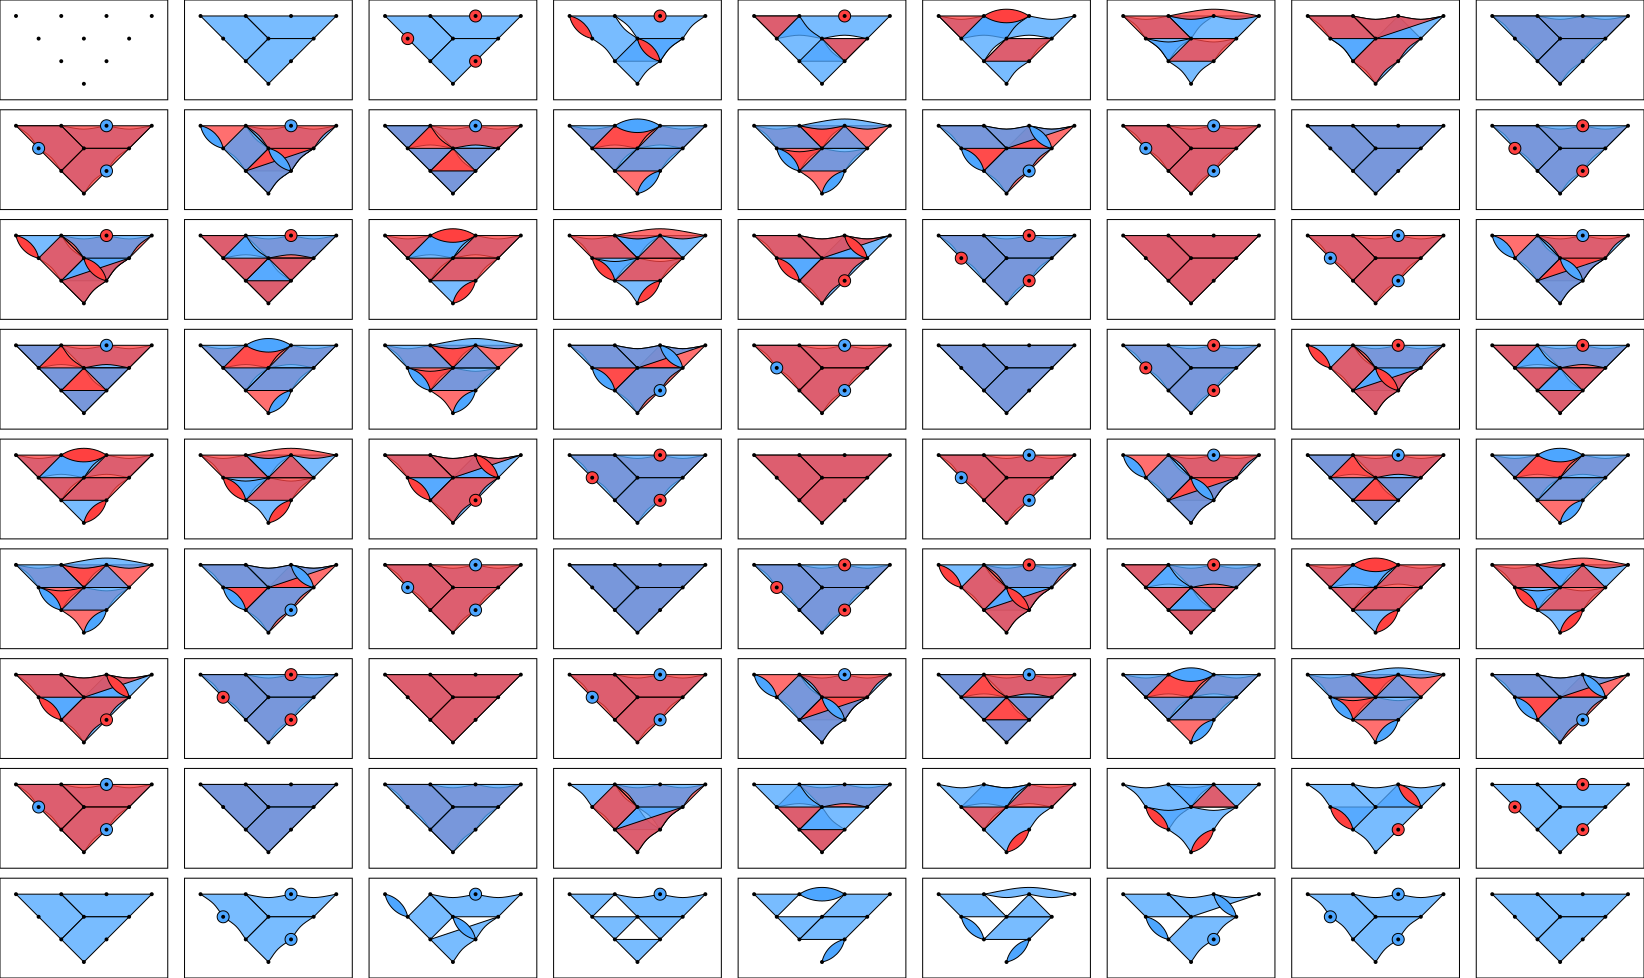

In [4]:
circ = ColorCodeCircuit666(3,5,0.01)
layout = circ._generate_layout(5)
c = circ.get_circuit()
print(c)
c.diagram("detslice-svg")

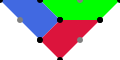

stim.Circuit('''
    QUBIT_COORDS(0, 0) 0
    QUBIT_COORDS(2, 0) 1
    QUBIT_COORDS(2, 2) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(3, 3) 4
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(6, 0) 6
    MPP Z0*Z1*Z2*Z3*Z4*Z5*Z6
    OBSERVABLE_INCLUDE(0) rec[-1]
    MPP X1*X3*X5*X6 X0*X1*X2*X3 X2*X3*X4*X5 Z1*Z3*Z5*Z6 Z0*Z1*Z2*Z3 Z2*Z3*Z4*Z5
    SHIFT_COORDS(0, 0, 1)
    TICK
    REPEAT 4 {
        MPP X1*X3*X5*X6 X0*X1*X2*X3 X2*X3*X4*X5 Z1*Z3*Z5*Z6 Z0*Z1*Z2*Z3 Z2*Z3*Z4*Z5
        DETECTOR(4, 0.5, 0, 1) rec[-6] rec[-12]
        DETECTOR(1.75, 0.75, 0, 2) rec[-5] rec[-11]
        DETECTOR(3.25, 1.75, 0, 0) rec[-4] rec[-10]
        DETECTOR(4, 0.5, 0, 4) rec[-3] rec[-9]
        DETECTOR(1.75, 0.75, 0, 5) rec[-2] rec[-8]
        DETECTOR(3.25, 1.75, 0, 3) rec[-1] rec[-7]
        SHIFT_COORDS(0, 0, 1)
        TICK
    }
    MPP X1*X3*X5*X6 X0*X1*X2*X3 X2*X3*X4*X5 Z1*Z3*Z5*Z6 Z0*Z1*Z2*Z3 Z2*Z3*Z4*Z5
    DETECTOR(4, 0.5, 0, 1) rec[-6] rec[-12]
    DETECTOR(1.75, 0.75, 0, 2) rec[-5] rec[-11]
    DETEC

In [5]:
from src.color_code_utils.color_code_circuits.color_code_chrom_circuit_666 import ColorCodeChromCircuit666
from src.color_code_utils.color_code_tile import draw_tiles

cc = ColorCodeChromCircuit666(3,5)
tiles = cc._make_color_code_tiles(3)
draw_tiles(tiles)
cc.get_circuit()

In [6]:
for d in [3, 5, 7, 9]:
    circ = ColorCodeCircuit666(distance=d, rounds=1, noise=0.001)
    print(f"Distance {d}: Data Qubits = {len(circ.qubits)} | Ancillas = {len(circ.ancilla)}")

for d in [3, 5, 7, 9]:
    circ_obj = ColorCodeCircuit666(distance=d, rounds=1)
    qs = sorted(list(q for tile in circ_obj._tiles for q in tile.qubits))
    logical_z = [q for q in qs if q[1] == 0]
    print(f"Distance {d}: Observable Weight = {len(logical_z)}")

Distance 3: Data Qubits = 7 | Ancillas = 3
Distance 5: Data Qubits = 19 | Ancillas = 9
Distance 7: Data Qubits = 37 | Ancillas = 18
Distance 9: Data Qubits = 61 | Ancillas = 30
Distance 3: Observable Weight = 4
Distance 5: Observable Weight = 8
Distance 7: Observable Weight = 12
Distance 9: Observable Weight = 16


In [9]:
for d in [3, 5, 7]:
    circ_obj = ColorCodeCircuit666(distance=d, rounds=1)
    # Re-calculate to ensure no variable contamination
    pure_qubits = {q for tile in circ_obj._tiles for q in tile.qubits}
    obs_qubits = sorted([q for q in pure_qubits if q[1] == 0])
    
    print(f"Distance {d}:")
    print(f"Total pure data qubits: {len(pure_qubits)}")
    print(f"Observable coordinates: {obs_qubits}")
    print("-" * 20)

Distance 3:
Total pure data qubits: 7
Observable coordinates: [(0, 0), (2, 0), (6, 0)]
--------------------
Distance 5:
Total pure data qubits: 19
Observable coordinates: [(0, 0), (2, 0), (6, 0), (8, 0), (12, 0)]
--------------------
Distance 7:
Total pure data qubits: 37
Observable coordinates: [(0, 0), (2, 0), (6, 0), (8, 0), (12, 0), (14, 0), (18, 0)]
--------------------


In [7]:
import sinter

circ = ColorCodeCircuit666(distance=5, rounds=5, noise=0.001).get_circuit()
# We use Sinter to find the shortest graphlike error. 
# Note: Chromobius handles the hypergraph, but this function will still 
# give you a lower-bound estimate of how many faults it takes to break the code.
shortest_error = circ.shortest_graphlike_error()
print(f"Expected effective distance for unflagged d=5 is 3.")
print(f"Actual graphlike fault distance: {len(shortest_error)}")

Expected effective distance for unflagged d=5 is 3.
Actual graphlike fault distance: 3


In [7]:
from dataclasses import dataclass
import stim
@dataclass
class ColorCodeTile:
    qubits: list
    ancilla: tuple
    color: str
    shape: int
class ColorCodeCircuit666Test:
    def within_bounds(self,x,y,side):
        if y<0:
            return False
        if x<y:
            return False
        if y>(side-1)-x:
            return False
        return True
        
    def generate_layout(self, distance:int):
        side = distance*3 - 2
        xtype = [['D', 'D', 'M'], ['M','D','D'], ['D','M','D']]
        dirs = [(-1,-1), (1,-1),(2,0),(1,1),(-1,1),(-2,0)]
        tiles = []
        validpos = set()
        for y in range(0, side):
            xpattern = xtype[y % 3]
            patternptr = 0
            for x in range(y,side-y,2):
                #print(x,y)
                currtype = xpattern[patternptr % 3]
                if currtype == 'M':
                    tile = ColorCodeTile(
                        qubits = [(x+dx, y+dy) for dx,dy in dirs if self.within_bounds(x+dx,y+dy,side)],
                        ancilla = (x,y),
                        color = ['red','green','blue'][y % 3],
                        shape = 6)
                    tiles.append(tile)
                patternptr += 1
        return tiles

    # based on https://github.com/quantumlib/chromobius/blob/main/doc/getting_started.ipynb
    def build_chrom_circuit(self, rounds:int, distance:int, after_clifford_depolarization:float, observable_basis=str):
       #'''Building a circuit using the chromobius docs - these don't explicitly use/declare ancilla qubits'''
        
        def mpp_targets(qubits:list, basis:str):
            '''Makes a pauli product for an MPP instruction '''
            target_basis = {'X':stim.target_x, 'Z':stim.target_z}[basis]
            idxs = sorted(qa_index_map[q] for q in qubits)
            targets = []
            for i in idxs:
                targets.append(target_basis(i))
                targets.append(stim.target_combiner())
            targets.pop()  # remove last combiner
            return targets
            
        def measure_observables():
            c = stim.Circuit()
            c.append("MPP", mpp_targets(sorted(qubits), observable_basis))
            c.append("OBSERVABLE_INCLUDE", stim.target_rec(-1), 0)
            return c
            
        def measure_stabilizers():
            c = stim.Circuit()

            for basis in ['X','Z']:
                for tile in tiles:
                    c.append("MPP", mpp_targets(tile.qubits, basis))
            
            num_stabilizers = len(tiles)*2
            for xz in range(2):
                for k, tile in enumerate(tiles):
                    ancilla  = tile.ancilla
                    chrom_color = {'red':0,'green':1,'blue':2}[tile.color]
                    chrom_annotation = chrom_color + 3*xz
                    offset = xz*len(tiles) + k
                    c.append("DETECTOR", [stim.target_rec(-(num_stabilizers - offset)), 
                                           stim.target_rec(-num_stabilizers*2+offset)],
                                           [ancilla[0], ancilla[1], 0, chrom_annotation])
            c.append("SHIFT_COORDS", [], [0,0,1])
            c.append("TICK")
            
            return c
        
        tiles = self.generate_layout(distance)
        
        qubits = {q for tile in tiles for q in tile.qubits}
        ancillae = {tile.ancilla for tile in tiles}
        sorted_q_a = sorted(qubits | ancillae)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        color_tiles = {'red':[tile for tile in tiles if tile.color=='red'],
                       'green':[tile for tile in tiles if tile.color=='green'],
                       'blue':[tile for tile in tiles if tile.color=="blue"]
                       }
        circuit = stim.Circuit()

        for q in qubits:
            idx = qa_index_map[q]
            circuit.append("QUBIT_COORDS", [idx], [q[0], q[1]])

        circuit += measure_observables()
        circuit += measure_stabilizers()
        circuit += (rounds-1) * measure_stabilizers()
        circuit += measure_stabilizers()
        circuit += measure_observables()

        return circuit

    def measure_stabilizers(self, circuit:stim.Circuit, tiles:dict, qa_index_map:dict, basis:str):
        ### group by edge orientation
        measure_dirs = [(1,-1),(2,0),(-1,-1),(1,1),(-2,0),(-1,1)]
        # collect all edges doing CNOTs in these dirs + do them together
        measured_a = []
        cnot_groups = {i:[] for i in range(6)}
        print(f"tiles {tiles}")
        for tile in tiles:
            (a1,a2) = tile.ancilla
            a_idx = qa_index_map[tile.ancilla]
            measured_a.append(a_idx)
            for i in range(6):
                (dx,dy) = measure_dirs[i]
                q = (a1+dx,a2+dy)
                if q in tile.qubits:
                    q_idx = qa_index_map[q]
                    if basis == 'X':
                        cnot_groups[i].extend([a_idx, q_idx])
                    else:
                        cnot_groups[i].extend([q_idx, a_idx])

        for i,group in cnot_groups.items():
            # add instruction to do CNOTs
            circuit.append("CNOT", group)
            circuit.append("TICK")
        if basis=='X':
            circuit.append("MRX", measured_a)
        else:
            circuit.append("MR", measured_a)

    def measure_stabilizers1(self, circuit:stim.Circuit, color:str, color_tiles:dict, qa_index_map:dict, basis:str):
        tilelist = color_tiles[color]
        ancilla_idxs = [qa_index_map[tile.ancilla] for tile in tilelist]

        
        #reset
        circuit.append("R", ancilla_idxs)
        circuit.append("TICK")
        # prepare ancilla qubits in the correct basis
        if basis == 'X':
            circuit.append("H", ancilla_idxs)
            circuit.append("TICK")

        cnot_ops = []
        for tile in tilelist:
            ancilla_idx = qa_index_map[tile.ancilla]
            for q in tile.qubits:
                data_idx = qa_index_map[q]
                if basis == 'X':
                    cnot_ops.extend([ancilla_idx, data_idx])
                else:
                    cnot_ops.extend([data_idx, ancilla_idx])
        if cnot_ops:
            circuit.append("CNOT", cnot_ops)
            circuit.append("TICK")
        
        #measurement
        circuit.append("M", ancilla_idxs)

        return ancilla_idxs

    def measure_rounds(self, circuit:stim.Circuit, tiles:dict, qa_index_map:dict, measures_per_round:int):
        loop = stim.Circuit()
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}

        # X 
        self.measure_stabilizers(loop,tiles,qa_index_map, 'X')
        for i, tile in enumerate(tiles):
            current_offset = -(len(tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['X']])

        loop.append("TICK")
        
        # Z
        self.measure_stabilizers(loop,tiles,qa_index_map, 'Z')
        for i, tile in enumerate(tiles):
            current_offset = -(len(tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), 
                                     stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])
        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop

    def measure_round_Z_0(self, tiles:dict, qa_index_map:dict):
        loop = stim.Circuit()
        total_m  = len(tiles)
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}

        self.measure_stabilizers(loop,tiles,qa_index_map,'Z')
        for i, tile in enumerate(tiles):
            loop.append("DETECTOR", [stim.target_rec(-(total_m - i))],[tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])

        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop
        
    def measure_rounds1(self, circuit:stim.Circuit, color_tiles:dict, qa_index_map:dict, measures_per_round:int):
        current_measure = 0
        loop = stim.Circuit()
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}

        for color, tilelist in color_tiles.items():
            ancilla_idxs = self.measure_stabilizers(loop, color, color_tiles, qa_index_map, basis='X')

            for i,tile in enumerate(tilelist):
                rec1 = stim.target_rec(-(len(ancilla_idxs)-i))
                rec2 = stim.target_rec(-(len(ancilla_idxs)-i+measures_per_round))

                loop.append("DETECTOR", [rec1, rec2], [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[color]['X']])
            current_measure += len(ancilla_idxs)
            loop.append("TICK")

            # Z basis 
            ancilla_idxs = self.measure_stabilizers(loop, color, color_tiles, qa_index_map, basis='Z')

            for i,tile in enumerate(tilelist):
                rec1 = stim.target_rec(-(len(ancilla_idxs)-i))
                rec2 = stim.target_rec(-(len(ancilla_idxs)-i+measures_per_round))

                loop.append("DETECTOR", [rec1, rec2], [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[color]['Z']])
            current_measure += len(ancilla_idxs)
            loop.append("TICK")
            
        return loop

    def build_circuit(self, rounds:int, distance:int, after_clifford_depolarization:float):
        tiles = self.generate_layout(distance)
        print(f"generated layout: {tiles}")
        circ = stim.Circuit()

        qubits = {q for tile in tiles for q in tile.qubits}
        ancillae = {tile.ancilla for tile in tiles}
        sorted_q_a = sorted(qubits | ancillae)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}
        colors = ['red','green','blue']
        
        # append coords to the circuit
        for q,i in qa_index_map.items():
            circ.append("QUBIT_COORDS", [i], [q[0], q[1]])

        # reset everything
        circ.append("R", [qa_index_map[q] for q in qubits])
        circ.append("R", [qa_index_map[a] for a in ancillae])
        circ.append("TICK")
        
        # round 0:
        self.measure_stabilizers(circ, tiles, qa_index_map, 'X')
        circ += self.measure_round_Z_0(tiles, qa_index_map)

        
        circ += (rounds-1) * self.measure_rounds(circ, tiles, qa_index_map, measures_per_round=2*len(tiles))

        
        
        # final z-detectors
        q_rec_offsets = {q_idx : -len(q_idxs) + k for k,q_idx in enumerate(q_idxs)}
        for i, tile in enumerate(tiles):
            targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in tile.qubits]
            a_offset = -len(q_idxs) - (len(tiles) - i)
            targets.append(stim.target_rec(a_offset))

            circ.append("DETECTOR", targets, [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])

        # logical observable
        logical_z_qubits = [q for q in sorted_qs if q[1]==0]
        #obs_targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in logical_z_qubits]
        obs_targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in [0,3,5]]
        circ.append("OBSERVABLE_INCLUDE", obs_targets, 0)
        
        return circ
        
circ = ColorCodeCircuit666Test()
layout = circ.generate_layout(3)
circ.build_circuit(2,3,0.001)
#circ.build_chrom_circuit(7,3,0.001,'X')
#print(circ.build_chrom_circuit(7,3,0.001,'X').decomposed())
#circ.build_circuit()
#print(f'\n\n NON CHROM :\n {circ.get_circuit()}')
circ.circuit.diagram("detslice")

generated layout: [ColorCodeTile(qubits=[(6, 0), (5, 1), (3, 1), (2, 0)], ancilla=(4, 0), color='red', shape=6), ColorCodeTile(qubits=[(0, 0), (2, 0), (3, 1), (2, 2)], ancilla=(1, 1), color='green', shape=6), ColorCodeTile(qubits=[(3, 1), (5, 1), (3, 3), (2, 2)], ancilla=(4, 2), color='blue', shape=6)]
tiles [ColorCodeTile(qubits=[(6, 0), (5, 1), (3, 1), (2, 0)], ancilla=(4, 0), color='red', shape=6), ColorCodeTile(qubits=[(0, 0), (2, 0), (3, 1), (2, 2)], ancilla=(1, 1), color='green', shape=6), ColorCodeTile(qubits=[(3, 1), (5, 1), (3, 3), (2, 2)], ancilla=(4, 2), color='blue', shape=6)]
tiles [ColorCodeTile(qubits=[(6, 0), (5, 1), (3, 1), (2, 0)], ancilla=(4, 0), color='red', shape=6), ColorCodeTile(qubits=[(0, 0), (2, 0), (3, 1), (2, 2)], ancilla=(1, 1), color='green', shape=6), ColorCodeTile(qubits=[(3, 1), (5, 1), (3, 3), (2, 2)], ancilla=(4, 2), color='blue', shape=6)]
tiles [ColorCodeTile(qubits=[(6, 0), (5, 1), (3, 1), (2, 0)], ancilla=(4, 0), color='red', shape=6), ColorCodeTi

NameError: name 'q_idxs' is not defined

In [2]:
#from ..abstract_color_code_circuit import AbstractColorCodeCircuit
#from ..color_code_tile import ColorCodeTile, draw_tiles
import stim
import numpy as np
import numpy.typing as npt
import ldpc.mod2.mod2_numpy as mod2

class ColorCodeCircuit666Test2():
    
    def __init__(self, distance, rounds, noise=None):
        #super().__init__(distance, rounds)
        self.distance = distance
        self.rounds = rounds
        self.qubits = set()
        self.ancilla = set()
        self._tiles = None
        self.qtoid = dict()
        self.circuit = self._build_circuit(noise)
        
        

    def get_circuit(self):
        return self.circuit
    
    def draw_layout(self):
        if self._tiles is None:
            return
        draw_tiles(self._tiles)

    def _generate_layout(self, distance:int):
        side = distance*3 - 2
        xtype = [['D', 'D', 'M'], ['M','D','D'], ['D','M','D']]
        dirs = [(-1,-1), (1,-1),(2,0),(1,1),(-1,1),(-2,0)]
        tiles = []
        for y in range(0, side):
            xpattern = xtype[y % 3]
            patternptr = 0
            for x in range(y,side-y,2):
                currtype = xpattern[patternptr % 3]
                if currtype == 'M':
                    #color_idx = (x//2 + y) % 3
                    tile_color = ['red','green','blue'][(x+y) % 3]
                    #tile_color = ['red','green','blue'][color_idx]
                    tile = ColorCodeTile(
                        qubits = [(x+dx, y+dy) for dx,dy in dirs if self._within_bounds(x+dx,y+dy,side)],
                        ancilla = (x,y),
                        color = tile_color,
                        shape = 6)
                    tiles.append(tile)
                patternptr += 1
        return tiles

    def _within_bounds(self,x,y,side):
        if y<0:
            return False
        if x<y:
            return False
        if y>(side-1)-x:
            return False
        return True

    def _build_circuit(self, noise=None):
        if noise is not None:
            addnoise = True
        else:
            addnoise = False
        tiles = self._generate_layout(self.distance)
        self._tiles = tiles
        circ = stim.Circuit()

        qubitsCoords = {q for tile in tiles for q in tile.qubits}
        ancillaCoords = {tile.ancilla for tile in tiles}
        sorted_q_a = sorted(qubitsCoords | ancillaCoords)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        self.qtoid = qa_index_map
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}
        self.qubits = {qa_index_map[q] for q in qubitsCoords}
        self.ancilla = {qa_index_map[a] for a in ancillaCoords}
        
        # append coords to the circuit
        for q,i in qa_index_map.items():
            circ.append("QUBIT_COORDS", [i], [q[0], q[1]])

        # reset everything
        circ.append("R", list(self.qubits))
        if addnoise:
            circ.append("X_ERROR",self.qubits, noise)
        circ.append("R", list(self.ancilla))
        if addnoise:
            circ.append("X_ERROR", self.ancilla, noise)
        circ.append("TICK")
        
        # round 0:
        #self._measure_stabilizers(circ, tiles, qa_index_map, 'X')
        circ += self._measure_round_Z_0(tiles, qa_index_map, chrom_annot=chrom_annot, noise=noise)

        
        circ += (self.rounds-1) * self._measure_rounds(tiles, qa_index_map, measures_per_round=2*len(tiles), chrom_annot=chrom_annot, noise=noise)

        # measure qubits
        sorted_qs = sorted(list(qubitsCoords))
        q_idxs = [qa_index_map[q] for q in sorted_qs]
        circ.append("M", q_idxs)
        
        # final z-detectors
        q_rec_offsets = {q_idx : -len(q_idxs) + k for k,q_idx in enumerate(q_idxs)}
        for i, tile in enumerate(tiles):
            targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in tile.qubits]
            a_offset = -len(q_idxs) - (len(tiles) - i)
            targets.append(stim.target_rec(a_offset))

            circ.append("DETECTOR", targets, [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])

        # logical observable
        logical_z_qubits = [q for q in sorted_qs if q[1]==0]
        #obs_targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in logical_z_qubits]
        
        stabs, mapping = self._get_stabilizers()
        Hx = np.array(stabs)
        Hz = np.array(stabs)
        #debugging assert
        assert np.all(Hx @ Hz.T % 2 == 0)
        log_arr = self._compute_logical(Hx,Hz)
        print(f"number of logicals {len(log_arr)}")
        target_idxs = self._translate_log(log_arr,mapping)
        obs_targets = [stim.target_rec(q_rec_offsets[q]) for q in target_idxs]
        print(target_idxs)
        circ.append("OBSERVABLE_INCLUDE", obs_targets, 0)
        
        
        return circ

    def _get_stabilizers(self):
        arr = []
        qub_index = {q:i for i,q in enumerate(self.qubits)}
        n = len(self.qubits)
        for tile in self._tiles:
            subarr = np.zeros(n)
            for q in tile.qubits:
                subarr[qub_index[self.qtoid[q]]] = 1
            arr.append(subarr)
        #print(f"result stabilizers: {arr}")
        return arr, qub_index

    def _translate_log(self, logical, mapping):
        relevant_idxs = {i for i,v in enumerate(logical[0]) if v==1}
        res_idxs = []
        for q,ind in mapping.items():
            if ind in relevant_idxs:
                res_idxs.append(q)
        return res_idxs
    
    #from https://github.com/munich-quantum-toolkit/qecc/blob/main/src/mqt/qecc/codes/css_code.py
    def _compute_logical(self, m1: npt.NDArray[np.int8], m2: npt.NDArray[np.int8]) -> npt.NDArray[np.int8]:
        """Compute the logical matrix L."""
        ker_m1 = mod2.nullspace(m1)  # compute the kernel basis of m1
        im_m2_transp = mod2.row_basis(m2)  # compute the image basis of m2
        log_stack = np.vstack([im_m2_transp, ker_m1])
        pivots = mod2.row_echelon(log_stack.T)[3]
        log_op_indices = [i for i in range(im_m2_transp.shape[0], log_stack.shape[0]) if i in pivots]
        return log_stack[log_op_indices]
        

    def _measure_round_Z_0(self, tiles:dict, qa_index_map:dict, chrom_annot:dict, noise=None):
        loop = stim.Circuit()
        total_m  = len(tiles)

        self._measure_stabilizers(loop,tiles,qa_index_map,'X', noise)
        self._measure_stabilizers(loop,tiles,qa_index_map,'Z', noise)
        for i, tile in enumerate(tiles):
            loop.append("DETECTOR", [stim.target_rec(-(total_m - i))],[tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])
        if noise is not None:
            loop.append("Z_ERROR", self.ancilla, noise)
            loop.append("X_ERROR", self.ancilla, noise)
        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop
    
    def _measure_rounds(self, tiles:dict, qa_index_map:dict, measures_per_round:int, chrom_annot:dict, noise=None):
        loop = stim.Circuit()
        if noise is not None:
            addnoise = True
        else:
            addnoise = False
        
        # X 
        self._measure_stabilizers(loop,tiles,qa_index_map, 'X', noise)
        for i, tile in enumerate(tiles):
            current_offset = -(len(tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['X']])
        if addnoise:
            loop.append("Z_ERROR", self.ancilla, noise)
        loop.append("TICK")
        
        # Z
        self._measure_stabilizers(loop,tiles,qa_index_map, 'Z', noise)
        for i, tile in enumerate(tiles):
            current_offset = -(len(tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), 
                                     stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])
        if addnoise:
            loop.append("X_ERROR", self.ancilla, noise)
        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop

    def _measure_stabilizers(self, circuit:stim.Circuit, tiles:dict, qa_index_map:dict, basis:str, noise=None):
        if noise is not None:
            addnoise = True
        else:
            addnoise = False
        # group by edge directions
        # order based on https://www.researchgate.net/publication/384079892_Improving_Threshold_for_Fault-Tolerant_Color-Code_Quantum_Computing_by_Flagged_Weight_Optimization
        measure_dirs = [(-1,-1),(1,-1),(-2,0),(2,0),(-1,1),(1,1)]
        #measure_dirs = [(1,-1),(2,0),(-1,-1),(1,1),(-2,0),(-1,1)]

        #TODO: add in flag gadgets implementation for reducing error-propagation paths
        # collect all edges doing CNOTs in these dirs + do them together
        measured_a = []
        cnot_groups = {i:[] for i in range(6)}
        for tile in tiles:
            (a1,a2) = tile.ancilla
            a_idx = qa_index_map[tile.ancilla]
            measured_a.append(a_idx)
            for i in range(6):
                (dx,dy) = measure_dirs[i]
                q = (a1+dx,a2+dy)
                if q in tile.qubits:
                    q_idx = qa_index_map[q]
                    if basis == 'X':
                        cnot_groups[i].extend([a_idx, q_idx])
                    else:
                        cnot_groups[i].extend([q_idx, a_idx])
        if basis == 'X':
            circuit.append("RX", measured_a)
            if addnoise:
                circuit.append("Z_ERROR", measured_a, noise)
        else:
            circuit.append("R", measured_a)
            if addnoise:
                circuit.append("X_ERROR", measured_a, noise)
        for i,group in cnot_groups.items():
            circuit.append("CNOT", group)
            if addnoise:
                circuit.append("DEPOLARIZE2", group, noise)
                #get unCNOTTED qubits in this operation
                circuit.append("DEPOLARIZE1", [q for q in self.qubits if q not in group], noise)
            circuit.append("TICK")
        if basis=='X':
            circuit.append("MX", measured_a)
        else:
            circuit.append("M", measured_a)
        if addnoise:
            circuit.append("DEPOLARIZE1", self.qubits, noise)


    def add_noise_model_to_circuit(self):
        pass

In [14]:
#from ..abstract_color_code_circuit import AbstractColorCodeCircuit
from src.color_code_utils.color_code_tile import ColorCodeTile, draw_tiles
import stim
import numpy as np
import numpy.typing as npt
import ldpc.mod2.mod2_numpy as mod2

class ColorCodeCircuit666BothBasis():
    
    def __init__(self, distance, rounds, noise=None, basis='Z'):
        #super().__init__(distance, rounds)
        self.basis = basis.upper()
        self.distance = distance
        self.rounds = rounds
        self.qubits = set()
        self.ancilla = set()
        self._tiles = None
        self.qtoid = dict()
        self.circuit = self._build_circuit(noise)     

    def get_circuit(self):
        return self.circuit
    
    def draw_layout(self):
        if self._tiles is None:
            return
        draw_tiles(self._tiles)

    def _generate_layout(self, distance:int):
        side = distance*3 - 2
        xtype = [['D', 'D', 'M'], ['M','D','D'], ['D','M','D']]
        dirs = [(-1,-1), (1,-1),(2,0),(1,1),(-1,1),(-2,0)]
        tiles = []
        for y in range(0, side):
            xpattern = xtype[y % 3]
            patternptr = 0
            for x in range(y,side-y,2):
                currtype = xpattern[patternptr % 3]
                if currtype == 'M':
                    #color_idx = (x//2 + y) % 3
                    tile_color = ['red','green','blue'][(x+y) % 3]
                    #tile_color = ['red','green','blue'][color_idx]
                    tile = ColorCodeTile(
                        qubits = [(x+dx, y+dy) for dx,dy in dirs if self._within_bounds(x+dx,y+dy,side)],
                        ancilla = (x,y),
                        color = tile_color,
                        shape = 6)
                    tiles.append(tile)
                patternptr += 1
        return tiles

    def _within_bounds(self,x,y,side):
        if y<0:
            return False
        if x<y:
            return False
        if y>(side-1)-x:
            return False
        return True

    def _build_circuit(self, noise=None):
        if noise is not None:
            addnoise = True
        else:
            addnoise = False
        tiles = self._generate_layout(self.distance)
        self._tiles = tiles
        circ = stim.Circuit()

        qubitsCoords = {q for tile in tiles for q in tile.qubits}
        ancillaCoords = {tile.ancilla for tile in tiles}
        sorted_q_a = sorted(qubitsCoords | ancillaCoords)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        self.qtoid = qa_index_map
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}
        self.qubits = {qa_index_map[q] for q in qubitsCoords}
        self.ancilla = {qa_index_map[a] for a in ancillaCoords}
        
        # append coords to the circuit
        for q,i in qa_index_map.items():
            circ.append("QUBIT_COORDS", [i], [q[0], q[1]])

        # reset everything
        if self.basis == 'Z':
            circ.append("R", list(self.qubits))
        else:
            circ.append("RX", list(self.qubits))
        
        if addnoise:
            circ.append("X_ERROR" if self.basis == 'Z' else "Z_ERROR",self.qubits, noise)

        circ.append("R", list(self.ancilla))
        if addnoise:
            circ.append("X_ERROR", self.ancilla, noise)
        circ.append("TICK")
        
        # round 0:
        #self._measure_stabilizers(circ, tiles, qa_index_map, 'X')
        circ += self._measure_round_0(tiles, qa_index_map, chrom_annot=chrom_annot, noise=noise)

        
        circ += (self.rounds-1) * self._measure_rounds(tiles, qa_index_map, measures_per_round=2*len(tiles), chrom_annot=chrom_annot, noise=noise)

        # measure qubits
        sorted_qs = sorted(list(qubitsCoords))
        q_idxs = [qa_index_map[q] for q in sorted_qs]

        measure_args = [q_idxs, noise] if addnoise else [q_idxs]

        if self.basis == 'Z':
            circ.append("M", *measure_args)
        else:
            circ.append("MX", *measure_args)

        # final detectors
        q_rec_offsets = {q_idx : -len(q_idxs) + k for k,q_idx in enumerate(q_idxs)}
        for i, tile in enumerate(tiles):
            targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in tile.qubits]
            if self.basis == 'Z':
                a_offset = -len(q_idxs) - (len(tiles) - i)
                detector_basis = chrom_annot[tile.color]['Z']
            else:
                a_offset = -len(q_idxs) - 2*len(tiles) + i
                detector_basis = chrom_annot[tile.color]['X']
            targets.append(stim.target_rec(a_offset))

            circ.append("DETECTOR", targets, [tile.ancilla[0], tile.ancilla[1], 1, detector_basis])

        # logical observable
        logical_z_qubits = [q for q in sorted_qs if q[1]==0]
        obs_targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in logical_z_qubits]
        circ.append("OBSERVABLE_INCLUDE", obs_targets, 0)
        
        return circ

    def _measure_round_0(self, tiles:dict, qa_index_map:dict, chrom_annot:dict, noise=None):
        loop = stim.Circuit()
        total_m  = len(tiles)

        self._measure_stabilizers(loop,tiles,qa_index_map,'X', noise)
        if self.basis == 'X':
            for i, tile in enumerate(tiles):
                loop.append("DETECTOR", [stim.target_rec(-(total_m - i))],[tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['X']])
        
        self._measure_stabilizers(loop,tiles,qa_index_map,'Z', noise)
        if self.basis == 'Z':
            for i, tile in enumerate(tiles):
                loop.append("DETECTOR", [stim.target_rec(-(total_m - i))],[tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])
        
        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop
    
    def _measure_rounds(self, tiles:dict, qa_index_map:dict, measures_per_round:int, chrom_annot:dict, noise=None):
        loop = stim.Circuit()
        
        # X 
        self._measure_stabilizers(loop,tiles,qa_index_map, 'X', noise)
        for i, tile in enumerate(tiles):
            current_offset = -(len(tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['X']])

        loop.append("TICK")
        
        # Z
        self._measure_stabilizers(loop,tiles,qa_index_map, 'Z', noise)
        for i, tile in enumerate(tiles):
            current_offset = -(len(tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), 
                                     stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])

        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop

    def _measure_stabilizers(self, circuit:stim.Circuit, tiles:dict, qa_index_map:dict, basis:str, noise=None):
        if noise is not None:
            addnoise = True
        else:
            addnoise = False
        # group by edge directions
        # order based on https://www.researchgate.net/publication/384079892_Improving_Threshold_for_Fault-Tolerant_Color-Code_Quantum_Computing_by_Flagged_Weight_Optimization
        measure_dirs = [(-1,-1),(1,-1),(-2,0),(2,0),(-1,1),(1,1)]
        #measure_dirs = [(1,-1),(2,0),(-1,-1),(1,1),(-2,0),(-1,1)]

        #TODO: add in flag gadgets implementation for reducing error-propagation paths
        # collect all edges doing CNOTs in these dirs + do them together
        measured_a = []
        cnot_groups = {i:[] for i in range(6)}
        for tile in tiles:
            (a1,a2) = tile.ancilla
            a_idx = qa_index_map[tile.ancilla]
            measured_a.append(a_idx)
            for i in range(6):
                (dx,dy) = measure_dirs[i]
                q = (a1+dx,a2+dy)
                if q in tile.qubits:
                    q_idx = qa_index_map[q]
                    if basis == 'X':
                        cnot_groups[i].extend([a_idx, q_idx])
                    else:
                        cnot_groups[i].extend([q_idx, a_idx])
        if basis == 'X':
            circuit.append("RX", measured_a)
            if addnoise:
                circuit.append("Z_ERROR", measured_a, noise)
        else:
            circuit.append("R", measured_a)
            if addnoise:
                circuit.append("X_ERROR", measured_a, noise)
        for i, group in cnot_groups.items():
            if not group: 
                continue 
    
            circuit.append("CNOT", group)
            
            if addnoise:
                circuit.append("DEPOLARIZE2", group, noise)
                
                # find all idling qubits (both data and ancilla)
                idle_qubits = [q for q in self.qubits if q not in group]
                idle_ancillas = [a for a in self.ancilla if a not in group]
                all_idling = idle_qubits + idle_ancillas
                
                # Apply idling noise to everything not in the CNOT group
                if all_idling:
                    circuit.append("DEPOLARIZE1", all_idling, noise)
                    
            circuit.append("TICK")

        measure_args = [measured_a, noise] if addnoise else [measured_a]

        if basis=='X':
            circuit.append("MX", *measure_args)
        else:
            circuit.append("M", *measure_args)
        if addnoise:
            circuit.append("DEPOLARIZE1", self.qubits, noise)


    def add_noise_model_to_circuit(self):
        pass

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(3, 1) 4
QUBIT_COORDS(3, 3) 5
QUBIT_COORDS(4, 0) 6
QUBIT_COORDS(4, 2) 7
QUBIT_COORDS(4, 4) 8
QUBIT_COORDS(5, 1) 9
QUBIT_COORDS(5, 3) 10
QUBIT_COORDS(5, 5) 11
QUBIT_COORDS(6, 0) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(6, 4) 14
QUBIT_COORDS(6, 6) 15
QUBIT_COORDS(7, 1) 16
QUBIT_COORDS(7, 3) 17
QUBIT_COORDS(7, 5) 18
QUBIT_COORDS(8, 0) 19
QUBIT_COORDS(8, 2) 20
QUBIT_COORDS(8, 4) 21
QUBIT_COORDS(9, 1) 22
QUBIT_COORDS(9, 3) 23
QUBIT_COORDS(10, 0) 24
QUBIT_COORDS(10, 2) 25
QUBIT_COORDS(11, 1) 26
QUBIT_COORDS(12, 0) 27
RX 0 2 3 4 5 9 10 11 12 13 14 15 19 20 21 22 23 26 27
R 1 6 7 8 16 17 18 24 25
TICK
RX 6 24 1 16 7 25 17 8 18
CX 1 0 16 12 7 4 25 22 17 13 8 5 18 14
TICK
CX 1 2 16 19 7 9 25 26 17 20 8 10 18 21
TICK
CX 6 2 24 19 16 9 7 3 25 20 17 10 18 11
TICK
CX 6 12 24 27 1 4 16 22 7 13 17 23 8 14
TICK
CX 6 4 24 22 16 13 7 5 25 23 17 14 18 15
TICK
CX 6 9 24 26 1 3 16 20 7 10 17 21 8 11
TICK
MX 6 24 1 1

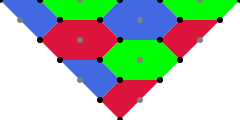

In [15]:
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import ColorCodeCircuit666
import svgwrite
from IPython.display import SVG, display
color_map = {
    'red':'crimson',
    'green':'lime',
    'blue':'royalblue'
    }

CC = ColorCodeCircuit666BothBasis(5,2, basis='X')
print(CC.get_circuit())
layout = CC._generate_layout(5)
print(CC.qtoid)
def draw_tiles(tiles):
    width = max(x for tile in tiles for x,y in tile.qubits)
    height = max(y for tile in tiles for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20, height*20))

    for tile in tiles:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))

draw_tiles(layout)

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(3, 1) 4
QUBIT_COORDS(3, 3) 5
QUBIT_COORDS(4, 0) 6
QUBIT_COORDS(4, 2) 7
QUBIT_COORDS(5, 1) 8
QUBIT_COORDS(6, 0) 9
RX 0 2 3 4 5 8 9
Z_ERROR(0.001) 0 2 3 4 5 8 9
R 1 6 7
X_ERROR(0.001) 1 6 7
TICK
RX 6 1 7
Z_ERROR(0.001) 6 1 7
TICK
CX 1 0 7 4
DEPOLARIZE2(0.001) 1 0 7 4
DEPOLARIZE1(0.001) 2 3 5 8 9 6
TICK
CX 1 2 7 8
DEPOLARIZE2(0.001) 1 2 7 8
DEPOLARIZE1(0.001) 0 3 4 5 9 6
TICK
CX 6 2 7 3
DEPOLARIZE2(0.001) 6 2 7 3
DEPOLARIZE1(0.001) 0 4 5 8 9 1
TICK
CX 6 9 1 4
DEPOLARIZE2(0.001) 6 9 1 4
DEPOLARIZE1(0.001) 0 2 3 5 8 7
TICK
CX 6 4 7 5
DEPOLARIZE2(0.001) 6 4 7 5
DEPOLARIZE1(0.001) 0 2 3 8 9 1
TICK
CX 6 8 1 3
DEPOLARIZE2(0.001) 6 8 1 3
DEPOLARIZE1(0.001) 0 2 4 5 9 7
TICK
MX(0.001) 6 1 7
DEPOLARIZE1(0.001) 0 2 3 4 5 8 9
DETECTOR(4, 0, 1, 1) rec[-3]
DETECTOR(1, 1, 1, 2) rec[-2]
DETECTOR(4, 2, 1, 0) rec[-1]
R 6 1 7
X_ERROR(0.001) 6 1 7
TICK
CX 0 1 4 7
DEPOLARIZE2(0.001) 0 1 4 7
DEPOLARIZE1(0.001) 2 3 

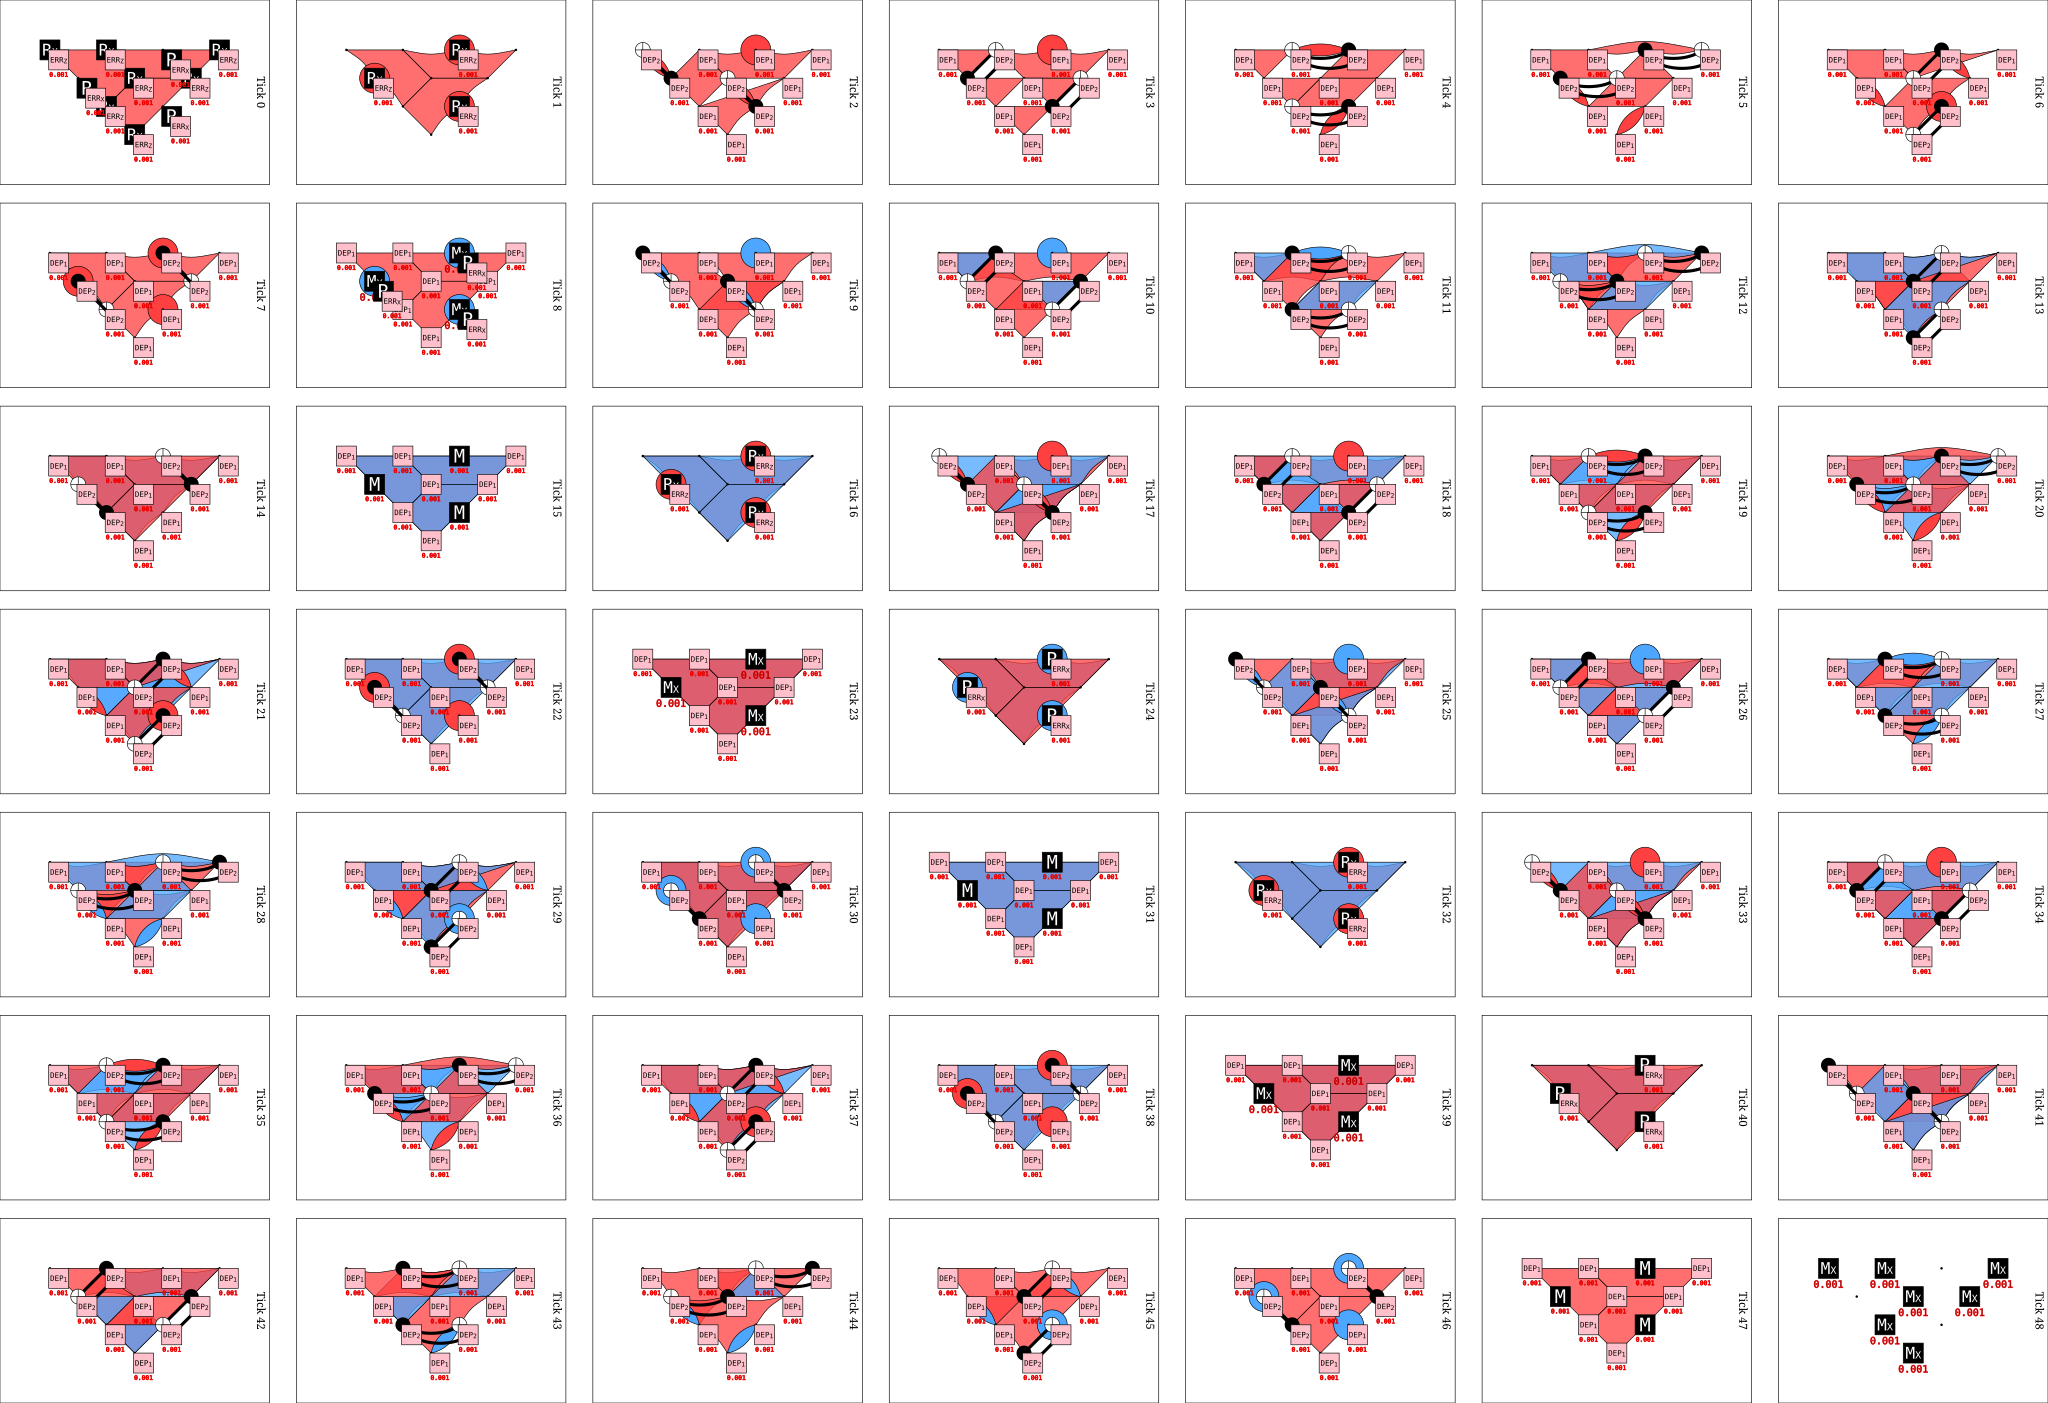

In [8]:
cc = ColorCodeCircuit666(3,3,1e-3, basis='X')
circ = cc.get_circuit()
print(circ)
circ.diagram('detslice-with-ops-svg')

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(3, 1) 4
QUBIT_COORDS(3, 3) 5
QUBIT_COORDS(4, 0) 6
QUBIT_COORDS(4, 2) 7
QUBIT_COORDS(5, 1) 8
QUBIT_COORDS(6, 0) 9
R 0 2 3 4 5 8 9
X_ERROR(0.001) 0 2 3 4 5 8 9
R 1 6 7
X_ERROR(0.001) 1 6 7
TICK
RX 6 1 7
Z_ERROR(0.001) 6 1 7
TICK
CX 1 0 7 4
DEPOLARIZE2(0.001) 1 0 7 4
DEPOLARIZE1(0.001) 2 3 5 8 9 6
TICK
CX 1 2 7 8
DEPOLARIZE2(0.001) 1 2 7 8
DEPOLARIZE1(0.001) 0 3 4 5 9 6
TICK
CX 6 2 7 3
DEPOLARIZE2(0.001) 6 2 7 3
DEPOLARIZE1(0.001) 0 4 5 8 9 1
TICK
CX 6 9 1 4
DEPOLARIZE2(0.001) 6 9 1 4
DEPOLARIZE1(0.001) 0 2 3 5 8 7
TICK
CX 6 4 7 5
DEPOLARIZE2(0.001) 6 4 7 5
DEPOLARIZE1(0.001) 0 2 3 8 9 1
TICK
CX 6 8 1 3
DEPOLARIZE2(0.001) 6 8 1 3
DEPOLARIZE1(0.001) 0 2 4 5 9 7
TICK
MX(0.001) 6 1 7
DEPOLARIZE1(0.001) 0 2 3 4 5 8 9
R 6 1 7
X_ERROR(0.001) 6 1 7
TICK
CX 0 1 4 7
DEPOLARIZE2(0.001) 0 1 4 7
DEPOLARIZE1(0.001) 2 3 5 8 9 6
TICK
CX 2 1 8 7
DEPOLARIZE2(0.001) 2 1 8 7
DEPOLARIZE1(0.001) 0 3 4 5 9 6
TICK
C

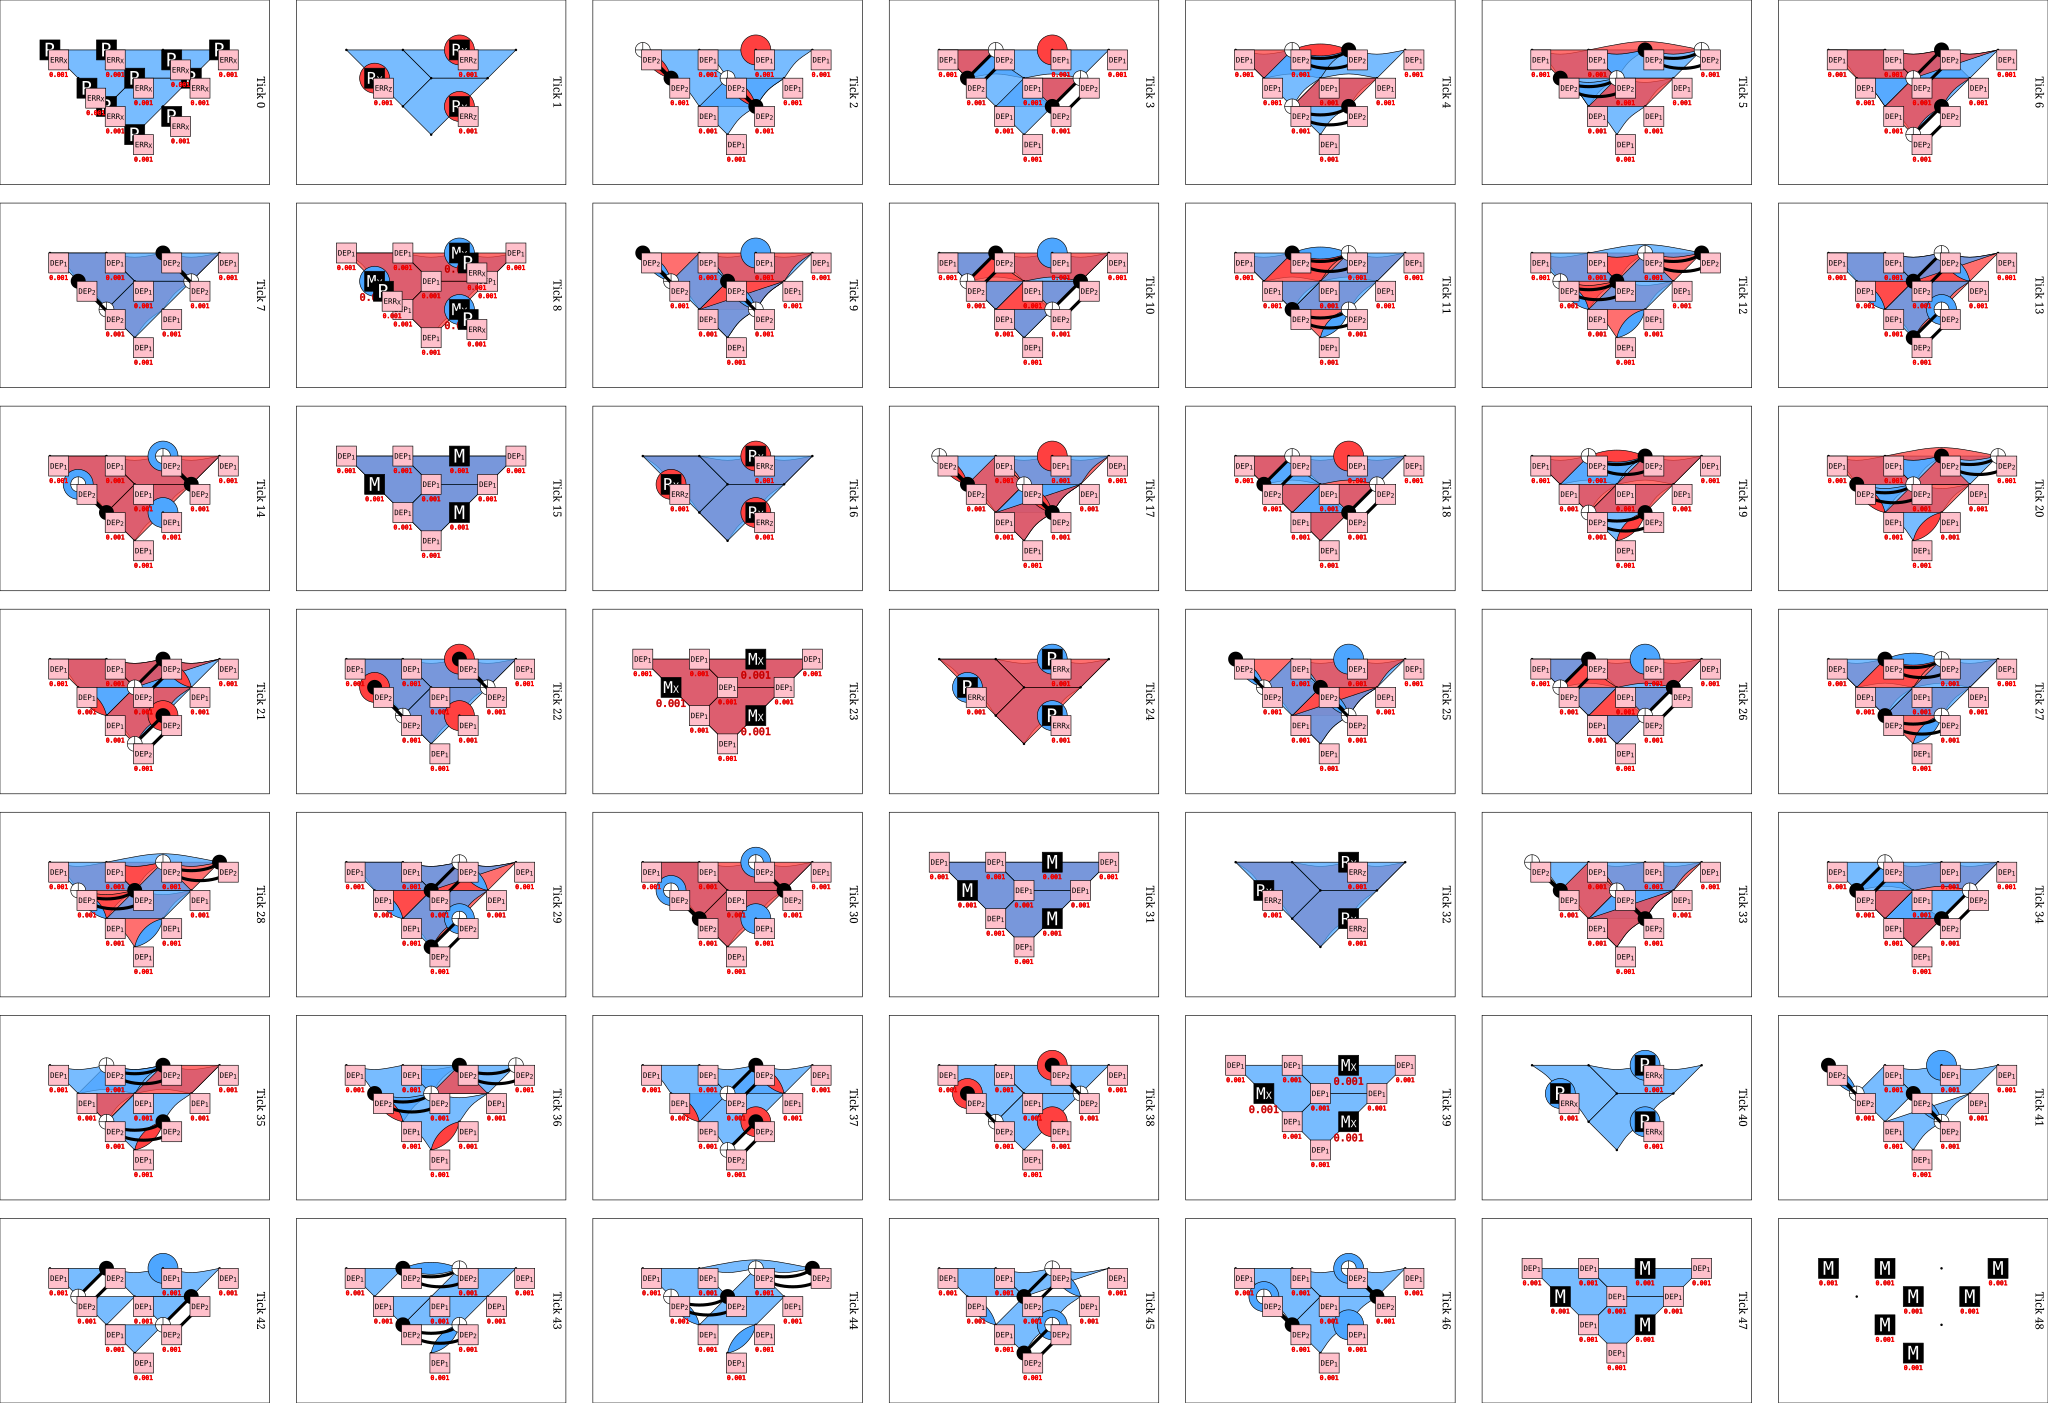

In [9]:
cc = ColorCodeCircuit666(3,3,1e-3, basis='Z')
circ = cc.get_circuit()
print(circ)
circ.diagram('detslice-with-ops-svg')

In [9]:

circuit = stim.Circuit.generated(
      "color_code:memory_xyz",
      rounds=2,
      distance=9,
      after_clifford_depolarization=1e-3
)

#print(str(circuit))
dem = circuit.detector_error_model()
#print(dem)
dem.diagram("matchgraph-3d")

{"accessors":[{"bufferView":0,"byteOffset":0,"componentType":5126,"count":9,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":1,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0,0.400000005960464],"min":[-0.400000005960464,0,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":2,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0.400000005960464,0],"min":[-0.400000005960464,-0.400000005960464,0],"name":"circle_loop","type":"VEC3"},{"bufferView":3,"byteOffset":0,"componentType":5126,"count":9,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":4,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0,0.400000005960464],"min":[-0.400000005960464,0,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":5,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0.400000005960464,0],"min":[-0.400000005960464,-0.400000005960464,0],"name":"circle_loop","type":"VEC3"},{"bufferView":6,"byteOffset":0,"componentType":5126,"count":312,"max":[33,42.8683471679688,7.85071229934692],"min":[0.382455825805664,-8.23906517028809,-4.85071229934692],"name":"buf_scattered_lines","type":"VEC3"},{"bufferView":7,"byteOffset":0,"componentType":5126,"count":104,"max":[41.2945022583008,9,4.3834285736084],"min":[-6.07279348373413,-7.21796560287476,-1.38342881202698],"name":"buf_red_scattered_lines","type":"VEC3"},{"bufferView":8,"byteOffset":0,"componentType":5126,"count":7772,"max":[33,33,3],"min":[1.5,0,0],"name":"buf_blue_scattered_lines","type":"VEC3"},{"bufferView":9,"byteOffset":0,"componentType":5126,"count":616,"max":[33,9,3],"min":[1.5,0,0],"name":"buf_purple_scattered_lines","type":"VEC3"}],"asset":{"version":"2.0"},"bufferViews":[{"buffer":0,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":1,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":2,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":3,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":4,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":5,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":6,"byteLength":3744,"byteOffset":0,"name":"buf_scattered_lines","target":34962},{"buffer":7,"byteLength":1248,"byteOffset":0,"name":"buf_red_scattered_lines","target":34962},{"buffer":8,"byteLength":93264,"byteOffset":0,"name":"buf_blue_scattered_lines","target":34962},{"buffer":9,"byteLength":7392,"byteOffset":0,"name":"buf_purple_scattered_lines","target":34962}],"buffers":[{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAM3MzD4AAAAAAAAAAMPQkD7D0JA+AAAAAPIwlrLNzMw+AAAAAMPQkL7D0JA+AAAAAM3MzL7yMBazAAAAAMHQkL7E0JC+AAAAAPLkozHNzMy+AAAAAMbQkD6/0JC+AAAAAM3MzD4AAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAAAAAADNzMw+w9CQPgAAAADD0JA+zczMPgAAAADyMJayw9CQPgAAAADD0JC+8jAWswAAAADNzMy+xNCQvgAAAADB0JC+zczMvgAAAADy5KMxv9CQvgAAAADG0JA+AAAAAAAAAADNzMw+"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,zczMPgAAAAAAAAAAw9CQPsPQkD4AAAAA8jCWss3MzD4AAAAAw9CQvsPQkD4AAAAAzczMvvIwFrMAAAAAwdCQvsTQkL4AAAAA8uSjMc3MzL4AAAAAxtCQPr/QkL4AAAAAzczMPgAAAAAAAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAM3MzD4AAAAAAAAAAMPQkD7D0JA+AAAAAPIwlrLNzMw+AAAAAMPQkL7D0JA+AAAAAM3MzL7yMBazAAAAAMHQkL7E0JC+AAAAAPLkozHNzMy+AAAAAMbQkD6/0JC+AAAAAM3MzD4AAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAAAAAADNzMw+w9CQPgAAAADD0JA+zczMPgAAAADyMJayw9CQPgAAAADD0JC+8jAWswAAAADNzMy+xNCQvgAAAADB0JC+zczMvgAAAADy5KMxv9CQvgAAAADG0JA+AAAAAAAAAADNzMw+"},{"byteLength":108,"name":"circle_loop","uri

In [29]:

cc = ColorCodeCircuit666BothBasis(9,2,1e-3, basis='Z')
circ = cc.get_circuit()
#print(circ)
dem2 = circ.detector_error_model()
#print(dem2)
dem2.diagram("matchgraph-3d")

{"accessors":[{"bufferView":0,"byteOffset":0,"componentType":5126,"count":9,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":1,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0,0.400000005960464],"min":[-0.400000005960464,0,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":2,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0.400000005960464,0],"min":[-0.400000005960464,-0.400000005960464,0],"name":"circle_loop","type":"VEC3"},{"bufferView":3,"byteOffset":0,"componentType":5126,"count":9,"max":[0,0.400000005960464,0.400000005960464],"min":[0,-0.400000005960464,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":4,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0,0.400000005960464],"min":[-0.400000005960464,0,-0.400000005960464],"name":"circle_loop","type":"VEC3"},{"bufferView":5,"byteOffset":0,"componentType":5126,"count":9,"max":[0.400000005960464,0.400000005960464,0],"min":[-0.400000005960464,-0.400000005960464,0],"name":"circle_loop","type":"VEC3"},{"bufferView":6,"byteOffset":0,"componentType":5126,"count":694,"max":[75.7463531494141,43.660758972168,10.6967544555664],"min":[-3.9841742515564,-8.82890319824219,-4.73166179656982],"name":"buf_scattered_lines","type":"VEC3"},{"bufferView":7,"byteOffset":0,"componentType":5126,"count":96,"max":[79.4402160644531,4.66666698455811,9.93821620941162],"min":[-0.641302108764648,-3.03428888320923,2.06178426742554],"name":"buf_red_scattered_lines","type":"VEC3"},{"bufferView":8,"byteOffset":0,"componentType":5126,"count":16484,"max":[70.4444427490234,34,9],"min":[5.22222185134888,0.333333343267441,3],"name":"buf_blue_scattered_lines","type":"VEC3"},{"bufferView":9,"byteOffset":0,"componentType":5126,"count":642,"max":[70.4444427490234,4.66666698455811,6],"min":[5.22222185134888,0.333333343267441,3],"name":"buf_purple_scattered_lines","type":"VEC3"}],"asset":{"version":"2.0"},"bufferViews":[{"buffer":0,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":1,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":2,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":3,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":4,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":5,"byteLength":108,"byteOffset":0,"name":"circle_loop","target":34962},{"buffer":6,"byteLength":8328,"byteOffset":0,"name":"buf_scattered_lines","target":34962},{"buffer":7,"byteLength":1152,"byteOffset":0,"name":"buf_red_scattered_lines","target":34962},{"buffer":8,"byteLength":197808,"byteOffset":0,"name":"buf_blue_scattered_lines","target":34962},{"buffer":9,"byteLength":7704,"byteOffset":0,"name":"buf_purple_scattered_lines","target":34962}],"buffers":[{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAM3MzD4AAAAAAAAAAMPQkD7D0JA+AAAAAPIwlrLNzMw+AAAAAMPQkL7D0JA+AAAAAM3MzL7yMBazAAAAAMHQkL7E0JC+AAAAAPLkozHNzMy+AAAAAMbQkD6/0JC+AAAAAM3MzD4AAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAAAAAADNzMw+w9CQPgAAAADD0JA+zczMPgAAAADyMJayw9CQPgAAAADD0JC+8jAWswAAAADNzMy+xNCQvgAAAADB0JC+zczMvgAAAADy5KMxv9CQvgAAAADG0JA+AAAAAAAAAADNzMw+"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,zczMPgAAAAAAAAAAw9CQPsPQkD4AAAAA8jCWss3MzD4AAAAAw9CQvsPQkD4AAAAAzczMvvIwFrMAAAAAwdCQvsTQkL4AAAAA8uSjMc3MzL4AAAAAxtCQPr/QkL4AAAAAzczMPgAAAAAAAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAM3MzD4AAAAAAAAAAMPQkD7D0JA+AAAAAPIwlrLNzMw+AAAAAMPQkL7D0JA+AAAAAM3MzL7yMBazAAAAAMHQkL7E0JC+AAAAAPLkozHNzMy+AAAAAMbQkD6/0JC+AAAAAM3MzD4AAAAA"},{"byteLength":108,"name":"circle_loop","uri":"data:application/octet-stream;base64,AAAAAAAAAADNzMw+w9CQPgAAAADD0JA+zczMPgAAAADyMJayw9CQPgAAAADD

In [11]:
circuit = stim.Circuit.generated(
      "color_code:memory_xyz",
      rounds=2,
      distance=5,
      after_clifford_depolarization=1e-3
)
print(str(circuit))

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(4, 0) 4
QUBIT_COORDS(5, 0) 5
QUBIT_COORDS(6, 0) 6
QUBIT_COORDS(0.5, 1) 7
QUBIT_COORDS(1.5, 1) 8
QUBIT_COORDS(2.5, 1) 9
QUBIT_COORDS(3.5, 1) 10
QUBIT_COORDS(4.5, 1) 11
QUBIT_COORDS(5.5, 1) 12
QUBIT_COORDS(1, 2) 13
QUBIT_COORDS(2, 2) 14
QUBIT_COORDS(3, 2) 15
QUBIT_COORDS(4, 2) 16
QUBIT_COORDS(5, 2) 17
QUBIT_COORDS(1.5, 3) 18
QUBIT_COORDS(2.5, 3) 19
QUBIT_COORDS(3.5, 3) 20
QUBIT_COORDS(4.5, 3) 21
QUBIT_COORDS(2, 4) 22
QUBIT_COORDS(3, 4) 23
QUBIT_COORDS(4, 4) 24
QUBIT_COORDS(2.5, 5) 25
QUBIT_COORDS(3.5, 5) 26
QUBIT_COORDS(3, 6) 27
R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
REPEAT 2 {
    TICK
    C_XYZ 0 1 3 4 6 8 9 11 12 13 15 16 18 19 21 23 24 25 27
    DEPOLARIZE1(0.001) 0 1 3 4 6 8 9 11 12 13 15 16 18 19 21 23 24 25 27
    TICK
    CX 8 7 3 2 15 14 23 22 11 10 21 20 6 5
    DEPOLARIZE2(0.001) 8 7 3 2 15 14 23 22 11 10 21 20 6 5
    TICK
    CX 13 7 9 2 19 14

In [17]:
circ = stim.Circuit("QUBIT_COORDS(0, 0) 0\nQUBIT_COORDS(4, 0) 1\nQUBIT_COORDS(7, 0) 2\n MPP Z0*Z1*Z2\nOBSERVABLE_INCLUDE(0) rec[-1]")
print(circ)
print(circ.decomposed())

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(4, 0) 1
QUBIT_COORDS(7, 0) 2
MPP Z0*Z1*Z2
OBSERVABLE_INCLUDE(0) rec[-1]
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(4, 0) 1
QUBIT_COORDS(7, 0) 2
CX 1 0 2 0
M 0
CX 1 0 2 0
OBSERVABLE_INCLUDE(0) rec[-1]


In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(4, 0) 1
QUBIT_COORDS(7, 0) 2
QUBIT_COORDS(9, 0) 3
QUBIT_COORDS(12, 0) 4
QUBIT_COORDS(16, 0) 5
QUBIT_COORDS(19, 0) 6
QUBIT_COORDS(21, 0) 7
QUBIT_COORDS(24, 0) 8
QUBIT_COORDS(1, 1) 9
QUBIT_COORDS(3, 1) 10
QUBIT_COORDS(6, 1) 11
QUBIT_COORDS(10, 1) 12
QUBIT_COORDS(13, 1) 13
QUBIT_COORDS(15, 1) 14
QUBIT_COORDS(18, 1) 15
QUBIT_COORDS(22, 1) 16
QUBIT_COORDS(4, 2) 17
QUBIT_COORDS(7, 2) 18
QUBIT_COORDS(9, 2) 19
QUBIT_COORDS(12, 2) 20
QUBIT_COORDS(16, 2) 21
QUBIT_COORDS(19, 2) 22
QUBIT_COORDS(21, 2) 23
QUBIT_COORDS(6, 3) 24
QUBIT_COORDS(10, 3) 25
QUBIT_COORDS(13, 3) 26
QUBIT_COORDS(15, 3) 27
QUBIT_COORDS(18, 3) 28
QUBIT_COORDS(7, 4) 29
QUBIT_COORDS(9, 4) 30
QUBIT_COORDS(12, 4) 31
QUBIT_COORDS(16, 4) 32
QUBIT_COORDS(10, 5) 33
QUBIT_COORDS(13, 5) 34
QUBIT_COORDS(15, 5) 35
QUBIT_COORDS(12, 6) 36
R 0 1 4 5 8 11 12 15 16 17 20 21 24 25 28 31 32 33 36
X_ERROR(0.001) 0 1 4 5 8 11 12 15 16 17 20 21 24 25 28 31 32 33 36
R 2 6 9 13 18 22 26 29 34
RX 3 7 10 14 19 23 27 30 

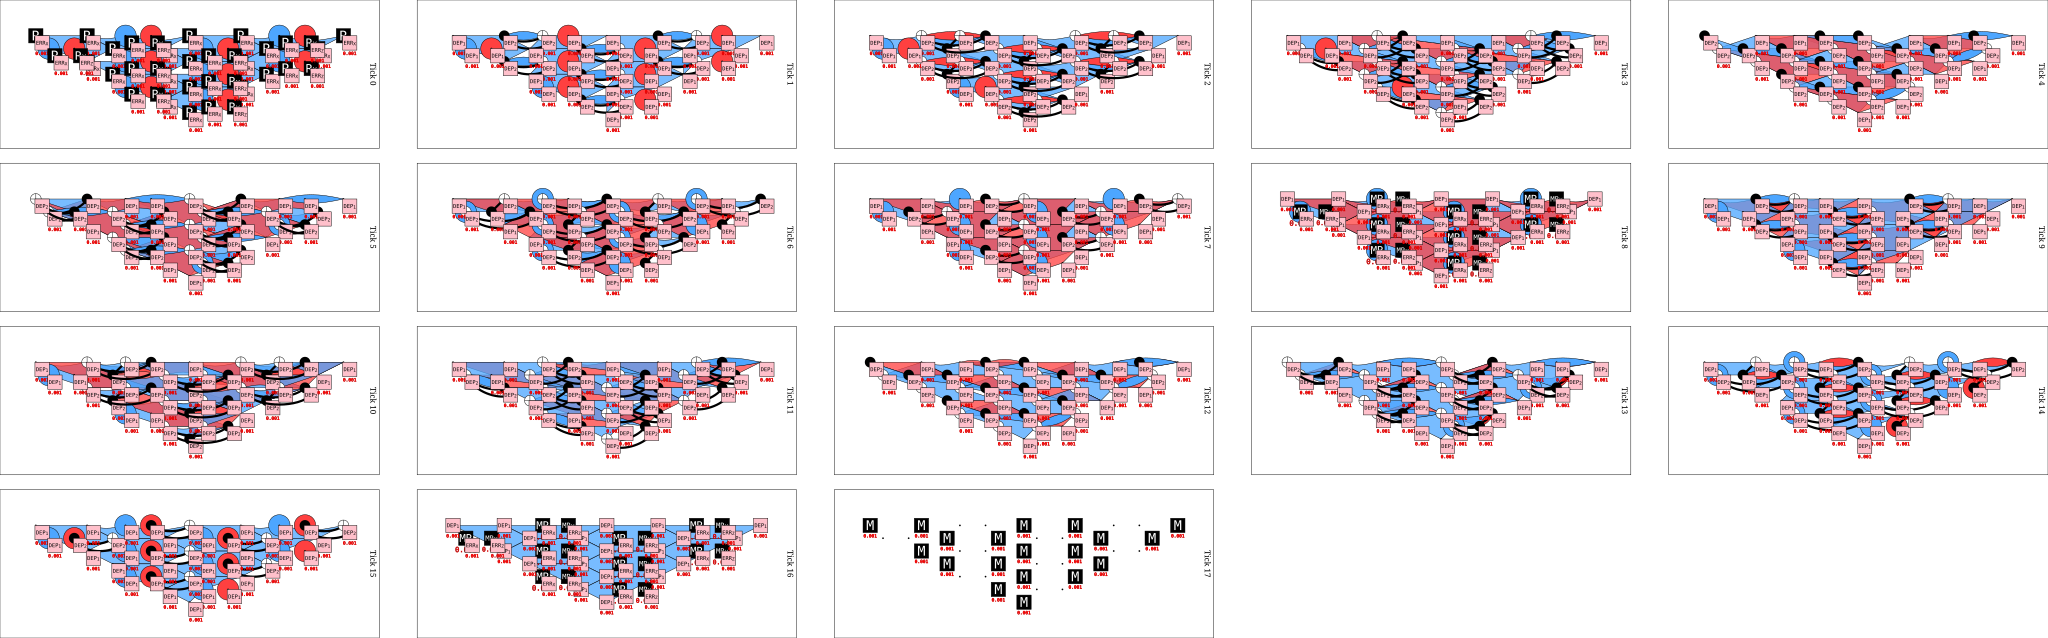

In [1]:
from color_code_stim import ColorCode,NoiseModel
import stim
noise = NoiseModel.uniform_circuit_noise(1e-3)
colorcode=ColorCode(d=3,rounds=2,circuit_type="tri", cnot_schedule="tri_optimal", noise_model=noise)
print(str(colorcode.circuit))
colorcode.circuit.diagram("detslice-with-ops-svg")

In [8]:
cc = ColorCodeCircuit666Test2(3,2,1e-3)
circ = cc.get_circuit()
print(circ)

NameError: name 'ColorCodeCircuit666Test2' is not defined

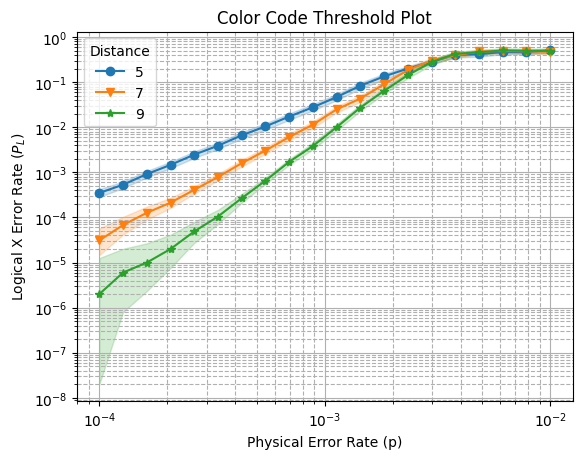

In [4]:
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius
import numpy as np

def generate_plot():
    distances = [3]
    noise_levels = np.logspace(-4, -2, 20)
    #noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01,]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d,r,p, basis='X').get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [5,7,9]
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=1000_000,
        max_errors=500,
        print_progress=False,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical X Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.legend(title='Distance')
    plt.savefig("ImplCCThresholdPlotXlogical")
    plt.show()
generate_plot()

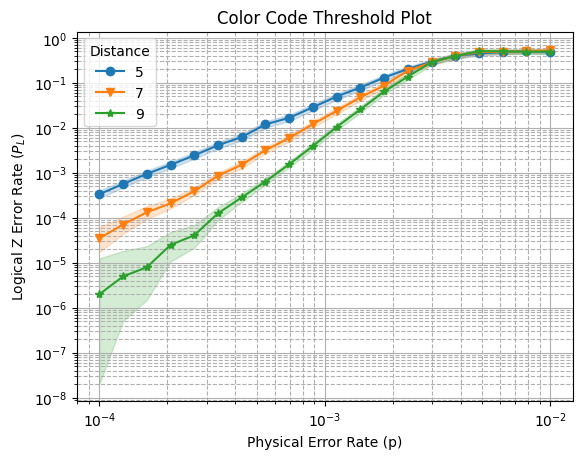

In [5]:
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius
import numpy as np

def generate_plot():
    distances = [3]
    noise_levels = np.logspace(-4, -2, 20)
    #noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01,]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d,r,p, basis='Z').get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [5,7,9]
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=1000_000,
        max_errors=500,
        print_progress=False,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Z Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.legend(title='Distance')
    plt.savefig("ImplCCThresholdPlotZlogical")
    plt.show()
generate_plot()

Estimated Threshold: 0.00526 ± 0.00538
Critical Exponent (nu): 3.000 ± 1.282


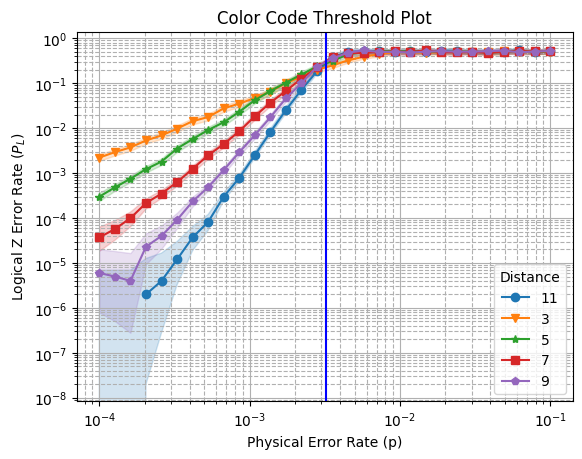

In [24]:
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius
import numpy as np
from scipy.optimize import curve_fit

def scaling_model(data_point, p_th, nu, a, b, c):
    p, d = data_point
    # The scaling variable
    x = (p - p_th) * (d ** (1/nu))
    # A simple quadratic fit for the universal function f(x)
    return a + b*x + c*(x**2)

def calculate_scientific_threshold(samples: List[sinter.TaskStats]):
    # 1. Extract raw data from sinter stats
    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    
    # Calculate logical error rate (add a tiny safety buffer to prevent divide-by-zero if shots=0)
    y = np.array([s.errors / max(s.shots, 1) for s in samples])
    
    # Check if we actually have non-zero data
    if np.all(y == 0):
        print("Error: All logical error rates are zero. The optimizer cannot fit flat data.")
        return None

    # 2. Fit the model with BOUNDS and higher MAXFEV
    p0 = [0.0032, 1.0, 0.01, 0.1, 0.1] 
    
    # Set physical bounds: 
    # p_th must be between 0.001 and 0.01 (based on your noise_levels)
    # nu should be positive (0.5 to 3.0 is typical for 2D codes)
    # a, b, c can be technically anything, so we use -np.inf to np.inf
    bounds = (
        [0.001, 0.5, -np.inf, -np.inf, -np.inf], # Lower bounds
        [0.010, 3.0,  np.inf,  np.inf,  np.inf]  # Upper bounds
    )
    
    try:
        popt, pcov = curve_fit(
            scaling_model, 
            (ps, ds), 
            y, 
            p0=p0, 
            bounds=bounds,
            maxfev=10000 # Increased from the default 800/1200
        )
        
        p_th_fit, nu_fit = popt[0], popt[1]
        perr = np.sqrt(np.diag(pcov)) 
        
        print(f"Estimated Threshold: {p_th_fit:.5f} ± {perr[0]:.5f}")
        print(f"Critical Exponent (nu): {nu_fit:.3f} ± {perr[1]:.3f}")
        return popt
        
    except RuntimeError as e:
        print(f"Fit failed completely: {e}")
        print("This usually means your data does not have a clear crossing point yet.")
        return None
        
def generate_plot():
    distances = [3]
    noise_levels = np.logspace(-4, -1, 30)
    #noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01,]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d,r,p).get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [3,5,7,9,11]
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=1000_000,
        max_errors=500,
        print_progress=False,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    calculate_scientific_threshold(samples)
    
    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Z Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.axvline(x = 0.0032, color = 'b')
    ax.legend(title='Distance')
    #plt.savefig("ImplCCThresholdPlot")
    plt.show()
generate_plot()


--- Calculating Scaling Threshold (Eq 16) ---
p*_th (Scaling): 0.00369 ± 0.00004

--- Calculating Cross Threshold (Eq 17) ---
p^x_th (Cross): 0.00305 ± 0.00009


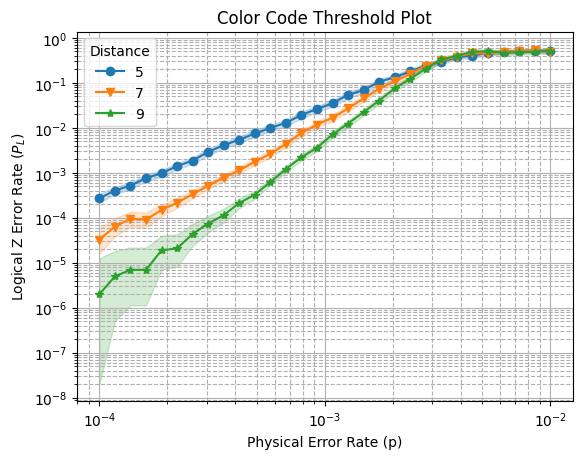

In [6]:
#### currently has the most recent calculate paper threshold script!
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius
import numpy as np
from scipy.optimize import curve_fit

# --- Model 1: Eq 16 ---
def scaling_threshold_model(data, c, p_th_star, alpha):
    p, d = data
    exponent = alpha * ((d + 1) / 2)
    # Using np.power and safe division to prevent warnings during optimization guesses
    return c * np.power(p / p_th_star, exponent)

# --- Model 2: Eq 17 ---
def cross_threshold_model(data, A, B, C, p_th_cross, v_0):
    p, d = data
    x = (p - p_th_cross) * (d ** (1 / v_0))
    return A + B * x + C * (x ** 2)


def calculate_paper_thresholds(samples: List[sinter.TaskStats], estimated_crossing: float = 0.0035):
    
    # 1. Extract raw data cleanly
    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    errors = np.array([s.errors for s in samples])
    
    y = errors / shots
    
    # 2. Calculate Statistical Weights (Handling zero-errors)
    y_err = np.sqrt(y * (1.0 - y) / shots)
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    # Initialize return variables so plotting doesn't crash if a fit fails
    popt_scale = None
    popt_cross = None

    # --- 3. Fit Scaling Threshold (Eq 16) ---
    print("\n--- Calculating Scaling Threshold (Eq 16) ---")
    low_p_mask = ps < (estimated_crossing * 0.8) 
    num_scale_points = np.sum(low_p_mask)
    
    if num_scale_points >= 3:
        p0_scale = [1.0, estimated_crossing, 1.0]
        bounds_scale = ([0.0, 0.0001, 0.1], [np.inf, 0.05, 5.0])
        try:
            popt_scale, pcov_scale = curve_fit(
                scaling_threshold_model, (ps[low_p_mask], ds[low_p_mask]), y[low_p_mask], 
                p0=p0_scale, bounds=bounds_scale, maxfev=10000,
                sigma=y_err[low_p_mask], absolute_sigma=True
            )
            perr_scale = np.sqrt(np.diag(pcov_scale))
            print(f"p*_th (Scaling): {popt_scale[1]:.5f} ± {perr_scale[1]:.5f}")
        except Exception as e:
            print(f"Fit failed: {e}")
    else:
        print(f"Skipped: Found only {num_scale_points} data points below p={estimated_crossing * 0.8}. Need at least 3.")

    # --- 4. Fit Cross Threshold (Eq 17) ---
    print("\n--- Calculating Cross Threshold (Eq 17) ---")
    unique_ps = np.unique(ps)
    closest_ps = sorted(unique_ps, key=lambda p: abs(p - estimated_crossing))[:5]
    
    near_p_mask = np.isin(ps, closest_ps)
    num_cross_points = np.sum(near_p_mask)
    
    if num_cross_points >= 5:
        p0_cross = [0.1, 10.0, 10.0, estimated_crossing, 1.0] 
        bounds_cross = (
            [0.0, -np.inf, -np.inf, 0.0001, 0.1], 
            [1.0,  np.inf,  np.inf, 0.05,  5.0]  
        )
        try:
            popt_cross, pcov_cross = curve_fit(
                cross_threshold_model, (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                p0=p0_cross, bounds=bounds_cross, maxfev=10000,
                sigma=y_err[near_p_mask], absolute_sigma=True 
            )
            perr_cross = np.sqrt(np.diag(pcov_cross))
            print(f"p^x_th (Cross): {popt_cross[3]:.5f} ± {perr_cross[3]:.5f}")
        except Exception as e:
            print(f"Fit failed: {e}")
    else:
        # THIS IS THE ERROR MESSAGE THAT WAS MISSING!
        print(f"Skipped: Found only {num_cross_points} points near threshold. Need at least 5 to fit Eq 17.")

    # Always return a tuple so your generate_plot() variable unpacking works safely
    return popt_scale, popt_cross
        
def generate_plot():
    distances = [3]
    noise_levels = np.logspace(-4, -2, 30)
    #noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01,]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d,r,p,basis='Z').get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [5,7,9]
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=1000_000,
        max_errors=500,
        print_progress=False,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    p1,p2 = calculate_paper_thresholds(samples, estimated_crossing=0.0035)
    
    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Z Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    #ax.axvline(x = p1[1], color = 'b', label="Scaling threshold")
    #ax.axvline(x = p2[3], color = 'r', label="Cross threshold")
    ax.legend(title='Distance')
    plt.savefig("ImplCCThresholdPlotNoThreshLines_ZL")
    plt.show()
generate_plot()

In [ ]:
#CALCULATING THRESHOLDS FOR 666 W X LOGICAL
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius
import numpy as np
from scipy.optimize import curve_fit

# --- Model 1: Eq 16 ---
def scaling_threshold_model(data, c, p_th_star, alpha):
    p, d = data
    exponent = alpha * ((d + 1) / 2)
    # Using np.power and safe division to prevent warnings during optimization guesses
    return c * np.power(p / p_th_star, exponent)

# --- Model 2: Eq 17 ---
def cross_threshold_model(data, A, B, C, p_th_cross, v_0):
    p, d = data
    x = (p - p_th_cross) * (d ** (1 / v_0))
    return A + B * x + C * (x ** 2)


def calculate_paper_thresholds(samples: List[sinter.TaskStats], estimated_crossing: float = 0.0025):
    # 1. Extract raw data
    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    y = np.array([s.errors / shots_i for s.errors, shots_i in zip([s.errors for s in samples], shots)])
    
    # 2. Calculate Statistical Weights (Standard error of a binomial distribution)
    # sigma = sqrt(p * (1-p) / N)
    y_err = np.sqrt(y * (1.0 - y) / shots)
    
    # Handle zero-error points by assigning them an error bounded by 1/shots 
    # so they still anchor the sub-threshold fit properly
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    # --- 3. Fit Scaling Threshold (Eq 16) ---
    print("\n--- Calculating Scaling Threshold (Eq 16) ---")
    # TIGHTEN WINDOW: Only use data deep in the sub-threshold regime (e.g., p < 0.8 * crossing)
    low_p_mask = ps < (estimated_crossing * 0.8) 
    
    if np.sum(low_p_mask) > 3:
        p0_scale = [1.0, estimated_crossing, 1.0]
        bounds_scale = ([0.0, 0.0001, 0.1], [np.inf, 0.05, 5.0])
        try:
            popt_scale, pcov_scale = curve_fit(
                scaling_threshold_model, (ps[low_p_mask], ds[low_p_mask]), y[low_p_mask], 
                p0=p0_scale, bounds=bounds_scale, maxfev=10000,
                sigma=y_err[low_p_mask], absolute_sigma=True # Weighting added here
            )
            perr_scale = np.sqrt(np.diag(pcov_scale))
            print(f"p*_th (Scaling): {popt_scale[1]:.5f} ± {perr_scale[1]:.5f}")
        except Exception as e:
            print(f"Scaling threshold fit failed: {e}")

    # --- 4. Fit Cross Threshold (Eq 17) ---
    print("\n--- Calculating Cross Threshold (Eq 17) ---")
    # TIGHTEN WINDOW: Takada & Fujii used exactly 5 distinct p values around the threshold.
    # Let's dynamically find the closest physical error rates to the estimated crossing.
    unique_ps = np.unique(ps)
    closest_ps = sorted(unique_ps, key=lambda p: abs(p - estimated_crossing))[:5]
    
    near_p_mask = np.isin(ps, closest_ps)
    
    if np.sum(near_p_mask) >= 5:
        p0_cross = [0.1, 10.0, 10.0, estimated_crossing, 1.0] 
        bounds_cross = (
            [0.0, -np.inf, -np.inf, 0.0001, 0.1], 
            [1.0,  np.inf,  np.inf, 0.05,  5.0]  
        )
        try:
            popt_cross, pcov_cross = curve_fit(
                cross_threshold_model, (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                p0=p0_cross, bounds=bounds_cross, maxfev=10000,
                sigma=y_err[near_p_mask], absolute_sigma=True # Weighting added here
            )
            perr_cross = np.sqrt(np.diag(pcov_cross))
            print(f"p^x_th (Cross): {popt_cross[3]:.5f} ± {perr_cross[3]:.5f}")
        except Exception as e:
            print(f"Cross threshold fit failed: {e}")
        
def generate_plot():
    distances = [3]
    noise_levels = np.logspace(-4, -2, 30)
    #noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01,]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d,r,p,,basis='X').get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [5,7,9]
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=1000_000,
        max_errors=500,
        print_progress=False,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    p1,p2 = calculate_paper_thresholds(samples, estimated_crossing=0.0025)
    
    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical X Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    #ax.axvline(x = p1[1], color = 'b', label="Scaling threshold")
    #ax.axvline(x = p2[3], color = 'r', label="Cross threshold")
    ax.legend(title='Distance')
    plt.savefig("ImplCCThresholdPlotNoThreshLines_XL")
    plt.show()
generate_plot()


--- Calculating Scaling Threshold (Eq 16) ---
p*_th (Scaling Threshold): 0.00312 ± 0.00004
alpha: 0.679 ± 0.010
c: 3.250e-01

--- Calculating Cross Threshold (Eq 17) ---
p^x_th (Cross Threshold): 0.00343 ± 0.00084
v_0 (Critical Exponent): 3.000 ± 1.724
A (Logical Error at Threshold): 0.31913


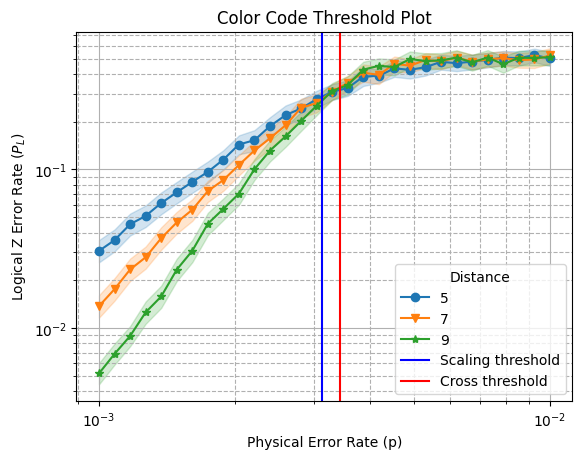

In [7]:
#ZOOMED IN THRESHOLDS GRAPH 666 Z LOGICAL
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius
import numpy as np
from scipy.optimize import curve_fit

# --- Model 1: Eq 16 ---
def scaling_threshold_model(data, c, p_th_star, alpha):
    p, d = data
    exponent = alpha * ((d + 1) / 2)
    # Using np.power and safe division to prevent warnings during optimization guesses
    return c * np.power(p / p_th_star, exponent)

# --- Model 2: Eq 17 ---
def cross_threshold_model(data, A, B, C, p_th_cross, v_0):
    p, d = data
    x = (p - p_th_cross) * (d ** (1 / v_0))
    return A + B * x + C * (x ** 2)


def calculate_paper_thresholds(samples: List[sinter.TaskStats], estimated_crossing: float = 0.0025):
    # 1. Extract raw data
    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    y = np.array([s.errors / shots_i for s.errors, shots_i in zip([s.errors for s in samples], shots)])
    
    # 2. Calculate Statistical Weights (Standard error of a binomial distribution)
    # sigma = sqrt(p * (1-p) / N)
    y_err = np.sqrt(y * (1.0 - y) / shots)
    
    # Handle zero-error points by assigning them an error bounded by 1/shots 
    # so they still anchor the sub-threshold fit properly
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    # --- 3. Fit Scaling Threshold (Eq 16) ---
    print("\n--- Calculating Scaling Threshold (Eq 16) ---")
    # TIGHTEN WINDOW: Only use data deep in the sub-threshold regime (e.g., p < 0.8 * crossing)
    low_p_mask = ps < (estimated_crossing * 0.8) 
    
    if np.sum(low_p_mask) > 3:
        p0_scale = [1.0, estimated_crossing, 1.0]
        bounds_scale = ([0.0, 0.0001, 0.1], [np.inf, 0.05, 5.0])
        try:
            popt_scale, pcov_scale = curve_fit(
                scaling_threshold_model, (ps[low_p_mask], ds[low_p_mask]), y[low_p_mask], 
                p0=p0_scale, bounds=bounds_scale, maxfev=10000,
                sigma=y_err[low_p_mask], absolute_sigma=True # Weighting added here
            )
            perr_scale = np.sqrt(np.diag(pcov_scale))
            print(f"p*_th (Scaling): {popt_scale[1]:.5f} ± {perr_scale[1]:.5f}")
        except Exception as e:
            print(f"Scaling threshold fit failed: {e}")

    # --- 4. Fit Cross Threshold (Eq 17) ---
    print("\n--- Calculating Cross Threshold (Eq 17) ---")
    # TIGHTEN WINDOW: Takada & Fujii used exactly 5 distinct p values around the threshold.
    # Let's dynamically find the closest physical error rates to the estimated crossing.
    unique_ps = np.unique(ps)
    closest_ps = sorted(unique_ps, key=lambda p: abs(p - estimated_crossing))[:5]
    
    near_p_mask = np.isin(ps, closest_ps)
    
    if np.sum(near_p_mask) >= 5:
        p0_cross = [0.1, 10.0, 10.0, estimated_crossing, 1.0] 
        bounds_cross = (
            [0.0, -np.inf, -np.inf, 0.0001, 0.1], 
            [1.0,  np.inf,  np.inf, 0.05,  5.0]  
        )
        try:
            popt_cross, pcov_cross = curve_fit(
                cross_threshold_model, (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                p0=p0_cross, bounds=bounds_cross, maxfev=10000,
                sigma=y_err[near_p_mask], absolute_sigma=True # Weighting added here
            )
            perr_cross = np.sqrt(np.diag(pcov_cross))
            print(f"p^x_th (Cross): {popt_cross[3]:.5f} ± {perr_cross[3]:.5f}")
        except Exception as e:
            print(f"Cross threshold fit failed: {e}")
        
def generate_plot():
    distances = [3]
    noise_levels = np.logspace(-3, -2, 30)
    #noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01,]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d,r,p, basis='Z').get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [5,7,9]
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=1000_000,
        max_errors=500,
        print_progress=False,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    p1,p2 = calculate_paper_thresholds(samples, estimated_crossing=0.0025)
    
    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Z Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.axvline(x = p1[1], color = 'b', label="Scaling threshold")
    ax.axvline(x = p2[3], color = 'r', label="Cross threshold")
    ax.legend(title='Distance')
    plt.savefig("ImplCCThresholdPlotWithThresholdLinesZoomed")
    plt.show()
generate_plot()


--- Calculating Scaling Threshold (Eq 16) ---
p*_th (Scaling Threshold): 0.00317 ± 0.00004
alpha: 0.695 ± 0.010
c: 3.501e-01

--- Calculating Cross Threshold (Eq 17) ---
p^x_th (Cross Threshold): 0.00307 ± 0.00079
v_0 (Critical Exponent): 3.000 ± 1.388
A (Logical Error at Threshold): 0.27767


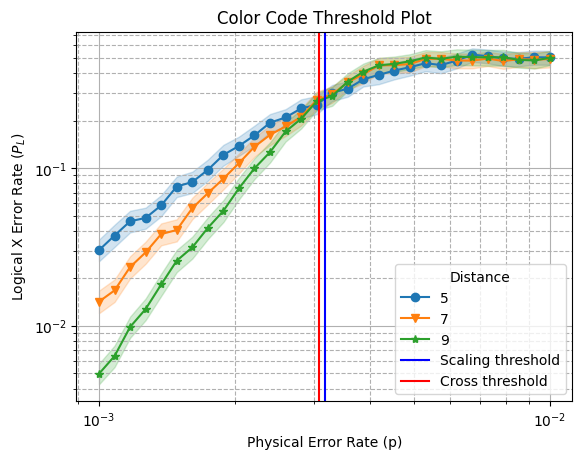

In [8]:
#ZOOMED IN THRESHOLDS GRAPH 666 X LOGICAL
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius
import numpy as np
from scipy.optimize import curve_fit

# --- Model 1: Eq 16 ---
def scaling_threshold_model(data, c, p_th_star, alpha):
    p, d = data
    exponent = alpha * ((d + 1) / 2)
    # Using np.power and safe division to prevent warnings during optimization guesses
    return c * np.power(p / p_th_star, exponent)

# --- Model 2: Eq 17 ---
def cross_threshold_model(data, A, B, C, p_th_cross, v_0):
    p, d = data
    x = (p - p_th_cross) * (d ** (1 / v_0))
    return A + B * x + C * (x ** 2)


def calculate_paper_thresholds(samples: List[sinter.TaskStats], estimated_crossing: float = 0.0025):
    # 1. Extract raw data
    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    y = np.array([s.errors / shots_i for s.errors, shots_i in zip([s.errors for s in samples], shots)])
    
    # 2. Calculate Statistical Weights (Standard error of a binomial distribution)
    # sigma = sqrt(p * (1-p) / N)
    y_err = np.sqrt(y * (1.0 - y) / shots)
    
    # Handle zero-error points by assigning them an error bounded by 1/shots 
    # so they still anchor the sub-threshold fit properly
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    # --- 3. Fit Scaling Threshold (Eq 16) ---
    print("\n--- Calculating Scaling Threshold (Eq 16) ---")
    # TIGHTEN WINDOW: Only use data deep in the sub-threshold regime (e.g., p < 0.8 * crossing)
    low_p_mask = ps < (estimated_crossing * 0.8) 
    
    if np.sum(low_p_mask) > 3:
        p0_scale = [1.0, estimated_crossing, 1.0]
        bounds_scale = ([0.0, 0.0001, 0.1], [np.inf, 0.05, 5.0])
        try:
            popt_scale, pcov_scale = curve_fit(
                scaling_threshold_model, (ps[low_p_mask], ds[low_p_mask]), y[low_p_mask], 
                p0=p0_scale, bounds=bounds_scale, maxfev=10000,
                sigma=y_err[low_p_mask], absolute_sigma=True # Weighting added here
            )
            perr_scale = np.sqrt(np.diag(pcov_scale))
            print(f"p*_th (Scaling): {popt_scale[1]:.5f} ± {perr_scale[1]:.5f}")
        except Exception as e:
            print(f"Scaling threshold fit failed: {e}")

    # --- 4. Fit Cross Threshold (Eq 17) ---
    print("\n--- Calculating Cross Threshold (Eq 17) ---")
    # TIGHTEN WINDOW: Takada & Fujii used exactly 5 distinct p values around the threshold.
    # Let's dynamically find the closest physical error rates to the estimated crossing.
    unique_ps = np.unique(ps)
    closest_ps = sorted(unique_ps, key=lambda p: abs(p - estimated_crossing))[:5]
    
    near_p_mask = np.isin(ps, closest_ps)
    
    if np.sum(near_p_mask) >= 5:
        p0_cross = [0.1, 10.0, 10.0, estimated_crossing, 1.0] 
        bounds_cross = (
            [0.0, -np.inf, -np.inf, 0.0001, 0.1], 
            [1.0,  np.inf,  np.inf, 0.05,  5.0]  
        )
        try:
            popt_cross, pcov_cross = curve_fit(
                cross_threshold_model, (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                p0=p0_cross, bounds=bounds_cross, maxfev=10000,
                sigma=y_err[near_p_mask], absolute_sigma=True # Weighting added here
            )
            perr_cross = np.sqrt(np.diag(pcov_cross))
            print(f"p^x_th (Cross): {popt_cross[3]:.5f} ± {perr_cross[3]:.5f}")
        except Exception as e:
            print(f"Cross threshold fit failed: {e}")
        
def generate_plot():
    distances = [3]
    noise_levels = np.logspace(-3, -2, 30)
    #noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01,]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d,r,p, basis='X').get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [5,7,9]
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=1000_000,
        max_errors=500,
        print_progress=False,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    p1,p2 = calculate_paper_thresholds(samples, estimated_crossing=0.0025)
    
    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical X Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.axvline(x = p1[1], color = 'b', label="Scaling threshold")
    ax.axvline(x = p2[3], color = 'r', label="Cross threshold")
    ax.legend(title='Distance')
    plt.savefig("ImplCCThresholdPlotWithThresholdLinesZoomed_XL")
    plt.show()
generate_plot()

In [17]:
import matplotlib.pyplot as plt  # <--- 1. Import added
import numpy as np

# Assuming ColorCode, NoiseModel, and colorcode are already imported from your library

def generate_plot2():
    distances = [3, 5, 7, 9, 11]
    noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01]
    res = {d:[] for d in distances}
    shots = 100_000
    
    print("Starting simulation...")
    
    # --- SIMULATION LOOP ---
    for d in distances:
        for r in [d]: # This loop is redundant but harmless
            for p in noise_levels:
                # 2. Fixed trailing comma bug below (removed comma at end of line)
                colorcode = ColorCode(
                    d=d, 
                    rounds=r, 
                    circuit_type="tri", 
                    cnot_schedule="tri_optimal", 
                    superdense=True,
                    noise_model=NoiseModel.uniform_circuit_noise(p)
                )

                # Run simulation
                num_fails, info = colorcode.simulate(
                    shots,  # Number of shots
                    full_output=True,  
                    verbose=False,
                    seed=42,
                ) 
                
                error_rate = num_fails / shots
                res[d].append(error_rate)
                print(f"d={d}, p={p}, failures={num_fails}")

    # --- PLOTTING LOGIC (Outside the loops) ---
    plt.figure(figsize=(10, 7))

    for d, logical_rates in res.items():
        plt.plot(
            noise_levels, 
            logical_rates, 
            label=f'd={d}', 
            marker='o', 
            linestyle='-', 
            linewidth=2
        )

    # 3. Fixed Matplotlib syntax (plt.title instead of plt.set_title)
    plt.xscale('log') # Use xscale/yscale for log plots
    plt.yscale('log')
    
    plt.title("Library Color Code Threshold Plot")
    plt.xlabel("Physical Error Rate (p)")
    plt.ylabel("Logical Error Rate ($P_L$)")
    
    plt.grid(which='major', linestyle='-')
    plt.grid(which='minor', linestyle='--', alpha=0.3)
    plt.legend(title='Distance')
    
    plt.tight_layout()
    plt.show()

# Run the function
generate_plot2()

Starting simulation...


TypeError: ColorCode.__init__() got an unexpected keyword argument 'superdense'

Starting 12 workers...
20 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata    
        1 pymatching          ?     100000         500 d=3,p=0.001,r=12 
        1 pymatching          ?     100000         500 d=3,p=0.002,r=12 
        1 pymatching          ?     100000         500 d=3,p=0.005,r=12 
        1 pymatching [draining]      98703        -124 d=3,p=0.01,r=12  
        1 pymatching          ?     100000         500 d=5,p=0.001,r=20 
        1 pymatching          ?     100000         500 d=5,p=0.002,r=20 
        1 pymatching          ?     100000         500 d=5,p=0.005,r=20 
        1 pymatching          ?     100000         500 d=5,p=0.01,r=20  
        1 pymatching          ?     100000         500 d=7,p=0.001,r=28 
        1 pymatching          ?     100000         500 d=7,p=0.002,r=28 
        1 pymatching          ?     100000         500 d=7,p=0.005,r=28 
        1 pymatching          ?     100000         500 d=7,p=0.01,r=28  
        0 pym

KeyError: 'source'

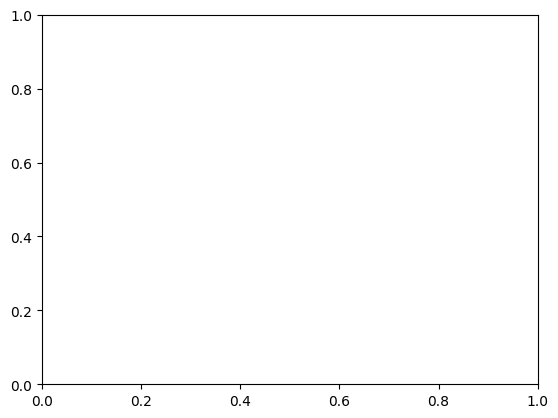

In [15]:
def generate_split_plot():
    # --- Collection A: My Code with BP-OSD ---
    noise_levels = [0.001, 0.002, 0.005, 0.01]
    tasks_my_code = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d, d, p).get_circuit(),
            json_metadata={'d': d, 'p': p, 'source': 'My Code'}
        )
        for d in [3, 5, 7, 9, 11]
        for r in [d*4]
        for p in noise_levels
    ]
    
    samples_A = sinter.collect(
        tasks=tasks_my_code,
        num_workers=4,
        max_shots=1000,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # --- Collection B: Library with Pymatching (e.g., if it supports decomposition) ---
    tasks_lib = [
        sinter.Task(
            circuit=ColorCode(d=d,rounds=r,circuit_type="tri", noise_model=NoiseModel.uniform_circuit_noise(p)).circuit,
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [3, 5, 7, 9, 11]
        for r in [d*4]
        for p in noise_levels
    ]

    # Run the samples
    samples_B = sinter.collect(
        tasks=tasks_lib,
        num_workers=os.cpu_count(),
        max_shots=100_000,
        max_errors=500,
        print_progress=True,
        decoders=['pymatching'],
        #custom_decoders=chromobius.sinter_decoders(),
    )

    # --- Combine and Plot ---
    all_samples = samples_A + samples_B # Merge lists
    
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=all_samples,
        x_func=lambda s: s.json_metadata['p'],
        # Group by Source is enough here, or include decoder if you want
        group_func=lambda s: f"{s.json_metadata['source']} ({s.decoder}) d={s.json_metadata['d']}",
        failure_units_per_shot_func=lambda s: 1,
    )
    ax.set_loglog()
    plt.show()

generate_split_plot()